# Rancangan Percobaan
Setiap penelitian dan pengembangan di bidang industri maupun akademik selalu berangkat dari pertanyaan yang sama yaitu, “Faktor apa yang benar-benar berpengaruh, dan bagaimana cara mengendalikannya?”. Pertanyaan sederhana ini melahirkan sebuah bidang yang dikenal sebagai rancangan percobaan.

Portofolio ini disusun sebagai dokumentasi perjalanan dalam mempelajari, memahami, dan menerapkan berbagai rancangan percobaan. Dari rancangan sederhana seperti One-Way ANOVA hingga rancangan kompleks seperti Response Surface Methodology (RSM), setiap bagian dirancang untuk menunjukkan bagaimana teori dapat diterapkan dalam kasus nyata.

Tujuan utama penyusunan portofolio ini bukan hanya menampilkan metode statistik, tetapi juga memperlihatkan logika ilmiah di balik setiap rancangan, serta bagaimana rancangan tersebut membantu pengambilan keputusan yang lebih baik di dunia nyata. Dengan pendekatan terstruktur, portofolio ini diharapkan dapat memberikan gambaran menyeluruh tentang variasi rancangan eksperimen yang relevan di berbagai konteks industri maupun penelitian.

# One-Way ANOVA + Post-hoc Tests

## Judul & Latar Belakang Masalah
**Pengaruh Temperature Pemanggangan terhadap Hardness Kue Kering**\
Sebuah pabrik makanan ingin mengetahui apakah variasi temperature pemanggangan memengaruhi tingkat hardness (kekerasan) kue kering yang diproduksi. Mereka menguji tiga temperature pemanggangan: 160°C, 170°C, dan 180°C. Hipotesisnya, semakin tinggi suhu, semakin keras kue, namun efeknya belum pasti.


## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian: Apakah terdapat perbedaan signifikan rata-rata hardness kue kering pada tiga temperature pemanggangan yang berbeda?
* Hipotesis:

  H₀: Tidak ada perbedaan rata-rata hardness antar temperature pemanggangan.

  H₁: Ada temperature yang menghasilkan rata-rata hardness berbeda.

## Desain Percobaan
* Jenis rancangan: One-Way ANOVA (Completely Randomized Design)
* Faktor: Temperature pemanggangan
* Level: 3 (160°C, 170°C, 180°C)
* Respon: Hardness kue (dalam Newton)
* Replikasi: 6 sampel per suhu
* Total sampel: 18 kue

## Analisis Statistik
* Hipotesis\
  H₀: μ₁ = μ₂ = μ₃ (rata-rata kekerasan sama untuk semua suhu: 160°C, 170°C, 180°C)\
  H₁: Setidaknya ada satu rata-rata yang berbeda.

### Import Library

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

### Dataset

In [2]:
data = {
    'temperature': ['160']*6 + ['170']*6 + ['180']*6,
    'hardness': [25.1, 24.8, 25.5, 24.9, 25.3, 25.0,
                  26.2, 26.0, 26.5, 27.0, 26.3, 26.7,
                  27.5, 28.0, 27.8, 28.3, 27.6, 28.1]
}
df = pd.DataFrame(data)
df.head()

,temperature,hardness
0,160,25.1
1,160,24.8
2,160,25.5
3,160,24.9
4,160,25.3


### One-Way ANOVA

In [5]:
model = ols('hardness ~ C(temperature)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(temperature),23.247778,2.0,119.151481,6.214160e-10
Residual,1.463333,15.0,NaN,NaN


In [6]:
alpha = 0.05
df_between = anova_table.df.iloc[0]
df_within = anova_table.df.iloc[1]
F_critical = stats.f.ppf(1 - alpha, df_between, df_within)
print(f"F-critical (alpha=0.05): {F_critical:.2f}")

F-critical (alpha=0.05): 3.68


* Hasil Uji One-Way ANOVA\
  F-statistic = 119.15\
  F-critical (α = 0.05, df_between = 2, df_within = 15) = 3.68\
  p-value = 6.21 x 10⁻¹⁰
* Interpretasi
  * H₀: rata-rata kekerasan sama untuk semua temperature.
  * Karena F-statistic (119.15) > F-critical (3.68), maka tolak H₀.
  * Karena p-value (6.21 x 10⁻¹⁰) < 0.05, maka tolak H₀.
  * Artinya: terdapat bukti sangat signifikan bahwa temperature pemanggangan mempengaruhi hardness kue.

###  Post-hoc (Tukey HSD)

In [7]:
tukey = pairwise_tukeyhsd(endog=df['hardness'],
                          groups=df['temperature'],
                          alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   160    170     1.35   0.0 0.8816 1.8184   True
   160    180   2.7833   0.0 2.3149 3.2517   True
   170    180   1.4333   0.0 0.9649 1.9017   True
-------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  160°C vs 170°C: perbedaan rata-rata = 1.35, signifikan (p < 0.05)\
  160°C vs 180°C: perbedaan rata-rata = 2.78, signifikan (p < 0.05)\
  170°C vs 180°C: perbedaan rata-rata = 1.43, signifikan (p < 0.05)
* Interpretasi Post-hoc
  * Semua pasangan temperature menunjukkan perbedaan signifikan.
  * Semakin tinggi temperature pemanggangan, semakin tinggi rata-rata hardness kue.
  * Peningkatan terbesar terjadi antara 160°C → 180°C (kenaikan ±2.78 N).

## Kesimpulan
Berdasarkan uji One-Way ANOVA, rata-rata hardness kue berbeda signifikan pada tiga tingkat temperature pemanggangan (160°C, 170°C, 180°C). Dengan kata lain, data menunjukkan bahwa perubahan temperature memang memengaruhi tingkat hardness kue.

## Rekomendasi
Untuk mendapatkan kue dengan kekerasan yang lebih tinggi, suhu pemanggangan yang lebih tinggi (180°C) dapat dipilih. Namun, jika target kekerasan lebih rendah atau sedang, suhu 170°C dapat menjadi kompromi yang stabil, sedangkan 160°C sebaiknya dihindari jika diperlukan struktur yang kokoh.

# Randomized Block Design (RBD)


## Judul & Latar Belakang Masalah
**Pengaruh Formulasi Lemak terhadap Crispness (Kerenyahan) pada Crackers dengan Mengontrol Preferensi Panelis**

Sebuah perusahaan makanan ringan ingin memilih formulation lemak terbaik untuk crackers agar menghasilkan tekstur crisp (renyah) yang disukai konsumen. Tiga formulation diuji: A (campuran minyak nabati), B (berbasis butter), dan C (campuran minyak zaitun). Karena preferensi panelis sensoris berbeda-beda, setiap panelis mengevaluasi ketiga formulation. Untuk mengontrol variasi antar panelis sebagai sumber gangguan, digunakan model Randomized Block Design (RBD) dengan panelis sebagai blok.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian:\
  Apakah terdapat perbedaan signifikan rata-rata skor crispness antar tiga formulation lemak (A, B, C) setelah mengontrol variasi antar panelis?
* Hipotesis:\
  H₀: μ_A = μ_B = μ_C (rata-rata crispness sama untuk ketiga formulation)\
  H₁: Setidaknya ada rata-rata yang berbeda.

## Desain Percobaan
* Treatment (faktor utama): Formulation lemak (A, B, C)
* Blok: Panelis (P1 sampai P6)
* Desain: Randomized Block Design (setiap panelis mencicipi dan memberi skor ketiga formulation)
* Skor respon: Crispness (skala sensorik 1-10)
* Total observasi: 6 panelis x 3 formulation = 18 observasi
* Randomisasi: Urutan penyajian difiksasi acak per panelis (diasumsikan telah diacak saat pengambilan data)

## Analisis Statistik

### Import Library

In [8]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Dataset

In [9]:
# Treatments: A = Vegetable oil blend, B = Butter-based, C = Olive oil blend
# Blocks: Panelists P1..P6 (each panelist tastes all 3 formulations)
data = [
    ['P1','A',6.5], ['P1','B',7.8], ['P1','C',5.9],
    ['P2','A',6.2], ['P2','B',7.5], ['P2','C',6.0],
    ['P3','A',6.8], ['P3','B',7.9], ['P3','C',5.6],
    ['P4','A',6.4], ['P4','B',7.6], ['P4','C',5.7],
    ['P5','A',6.1], ['P5','B',7.4], ['P5','C',5.8],
    ['P6','A',6.7], ['P6','B',7.7], ['P6','C',5.9],
]

df = pd.DataFrame(data, columns=['panelist','formulation','crispness'])
df.head()

,panelist,formulation,crispness
0,P1,A,6.5
1,P1,B,7.8
2,P1,C,5.9
3,P2,A,6.2
4,P2,B,7.5


### Randomized Block Design (RBD) model


In [11]:
model = ols('crispness ~ C(formulation) + C(panelist)', data=df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(formulation),10.404444,2.0,138.520710,5.131888e-08
C(panelist),0.282778,5.0,1.505917,2.715972e-01
Residual,0.375556,10.0,NaN,NaN


In [12]:
alpha = 0.05
df_between = anova_table.loc['C(formulation)','df']
df_between1 = anova_table.loc['C(panelist)','df']
df_within = anova_table.loc['Residual','df']
F_critical = stats.f.ppf(1-alpha, df_between, df_within)
F_critical1 = stats.f.ppf(1-alpha, df_between1, df_within)
print(f"F-critical (alpha=0.05, df_between = 2, df_within = 10): {F_critical:.2f}")
print(f"F-critical (alpha=0.05, df_between = 5, df_within = 10): {F_critical1:.2f}")

F-critical (alpha=0.05, df_between = 2, df_within = 10): 4.10
F-critical (alpha=0.05, df_between = 5, df_within = 10): 3.33


* Hipotesis\
  H₀ (Formulation): μ_A = μ_B = μ_C (rata-rata crispness ketiga formulation sama)\
  H₁ (Formulation): Setidaknya ada dua formulation yang berbeda secara signifikan.\
  H₀ (Panelist): Tidak ada perbedaan rata-rata skor antar panelis.\
  H₁ (Panelist): Ada perbedaan rata-rata skor antar panelis.
* Hasil Uji ANOVA
  * Formulation
    F-statistic = 138.52\
    F-critical (α = 0.05, df_between = 2, df_within = 10) = 4.10\
    p-value = 5.13 x 10⁻⁸
  * Panelist
    F-statistic = 1.51\
    F-critical (alpha=0.05, df_between = 5, df_within = 10) = 3.33\
    p-value = 2.72 x 10⁻¹
* Interpretasi
  * Efek Panelist (blok): F ≈ 1.51, p ≈ 0.2716 (tidak signifikan pada α=0.05), yang berarti variasi antar panelis tidak berbeda secara statistik kuat, namun tetap dikontrol sebagai blok.
  * H₀: rata-rata crispness sama untuk ketiga formulation
  * Karena F-statistic (138.52) > F-critical (4.10), maka tolak H₀.
  * Karena p-value = 5.13 x 10⁻⁸ < 0.05, maka tolak H₀.
  * Artinya: terdapat perbedaan signifikan rata-rata crispness antar formulation

### Post-hoc (Tukey HSD)

In [14]:
tukey = pairwise_tukeyhsd(endog=df['crispness'],
                          groups=df['panelist'],
                          alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    P1     P2  -0.1667 0.9999 -2.7661 2.4327  False
    P1     P3   0.0333    1.0 -2.5661 2.6327  False
    P1     P4  -0.1667 0.9999 -2.7661 2.4327  False
    P1     P5     -0.3 0.9986 -2.8994 2.2994  False
    P1     P6   0.0333    1.0 -2.5661 2.6327  False
    P2     P3      0.2 0.9998 -2.3994 2.7994  False
    P2     P4      0.0    1.0 -2.5994 2.5994  False
    P2     P5  -0.1333    1.0 -2.7327 2.4661  False
    P2     P6      0.2 0.9998 -2.3994 2.7994  False
    P3     P4     -0.2 0.9998 -2.7994 2.3994  False
    P3     P5  -0.3333 0.9976 -2.9327 2.2661  False
    P3     P6      0.0    1.0 -2.5994 2.5994  False
    P4     P5  -0.1333    1.0 -2.7327 2.4661  False
    P4     P6      0.2 0.9998 -2.3994 2.7994  False
    P5     P6   0.3333 0.9976 -2.2661 2.9327  False
---------------------------------------------------


In [15]:
tukey = pairwise_tukeyhsd(endog=df['crispness'], groups=df['formulation'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B      1.2    0.0  0.8858  1.5142   True
     A      C  -0.6333 0.0003 -0.9475 -0.3192   True
     B      C  -1.8333    0.0 -2.1475 -1.5192   True
----------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  A vs B: perbedaan rata-rata = 1.2, signifikan (p < 0.05)\
  A vs C: perbedaan rata-rata = -0.63, signifikan (p < 0.05)\
  B vs C: perbedaan rata-rata = -1.83, signifikan (p < 0.05)
* Interpretasi Post-hoc
  * Semua pasangan formulation menunjukkan perbedaan signifikan.
  * Formulasi B menghasilkan crispness tertinggi, diikuti A, dan C terendah.
  * Variasi antar panelis tidak signifikan, sehingga perbedaan skor utama disebabkan oleh formulation, bukan selera panelis.

## Kesimpulan
* Berdasarkan hasil analisis Randomized Block Design (RBD), terdapat perbedaan signifikan rata-rata crispness antar formulation lemak.
* Formulasi B memberikan skor crispness tertinggi, diikuti oleh A, sedangkan C menunjukkan skor terendah
* Efek blok (panelis) tidak signifikan yang berarti variasi penilaian antar panelis relatif kecil dibandingkan pengaruh formulation.

## Rekomendasi
* Gunakan Formulasi B (butter-based) jika tujuan utama adalah menghasilkan crackers dengan tingkat crispness optimal.
* Formulasi A dapat dipertimbangkan sebagai alternatif, apabila faktor biaya atau ketersediaan bahan baku menjadi pertimbangan, karena masih memberikan skor menengah yang signifikan lebih tinggi dibanding C.
* Formulasi C perlu ditinjau ulang, misalnya dengan mengoptimalkan komposisi minyak zaitun atau mengkombinasikannya dengan teknik pemanggangan yang berbeda.
* Untuk pengembangan lebih lanjut, lakukan percobaan skala besar dengan lebih banyak panelis dan variasi proses (misalnya waktu pemanggangan atau suhu), menggunakan rancangan faktorial atau split-plot untuk mengevaluasi interaksi antar faktor.

# Latin Square Design

## Judul & Latar Belakang Masalah
**Pengaruh Tiga Metode Fermentasi Terhadap Rasa Roti dengan Pengendalian Faktor Hari Produksi dan Panelis**\
Dalam industri bakery, rasa roti dipengaruhi oleh berbagai faktor, termasuk metode fermentasi yang digunakan, hari produksi (karena perubahan suhu dan kelembapan ruangan), dan karakteristik subjektif panelis penilai rasa. Untuk mendapatkan hasil yang valid, perlu dilakukan percobaan yang mampu mengendalikan dua sumber variasi selain faktor utama. Desain Latin Square dipilih karena dapat mengontrol dua sumber variasi (baris dan kolom), sehingga pengaruh utama yang diuji (metode fermentasi) dapat lebih jelas terlihat.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan Penelitian:\
Apakah terdapat perbedaan signifikan dalam skor rasa roti yang dihasilkan dari tiga metode fermentasi yang berbeda setelah mengendalikan faktor hari produksi dan panelis?
* Hipotesis:\
  H₀: Tidak ada perbedaan signifikan rata-rata skor rasa antar metode fermentasi.\
  H₁: Ada perbedaan signifikan rata-rata skor rasa minimal pada satu metode fermentasi.

## Desain Percobaan
* Faktor utama: Metode fermentasi (A, B, C)
* Faktor pengendali baris: Hari produksi (3 hari)
* Faktor pengendali kolom: Panelis (3 panelis)
* Respon: Skor rasa roti (skala 1-10)
* Setiap metode fermentasi diuji sekali per kombinasi hari-panelis sehingga membentuk matriks 3x3 (Latin Square).
* Contoh layout:

|        | Panelis 1 | Panelis 2 | Panelis 3 |
| ------ | --------- | --------- | --------- |
| Hari 1 | A         | B         | C         |
| Hari 2 | B         | C         | A         |
| Hari 3 | C         | A         | B         |


## Analisis Statistik

### Import Library

In [16]:
import pandas as pd
from scipy.stats import f
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Dataset

In [17]:
# Data skor rasa
data = {
    'day':    ['D1','D1','D1','D2','D2','D2','D3','D3','D3'],
    'panelist': ['P1','P2','P3','P1','P2','P3','P1','P2','P3'],
    'fermentation': ['A','B','C','B','C','A','C','A','B'],
    'score': [7.2, 7.8, 7.5,   # day 1
             7.6, 8.0, 7.3,   # day 2
             7.4, 7.1, 7.9]   # day 3
}
df = pd.DataFrame(data)
df.head()

,day,panelist,fermentation,score
0,D1,P1,A,7.2
1,D1,P2,B,7.8
2,D1,P3,C,7.5
3,D2,P1,B,7.6
4,D2,P2,C,8.0


### Model Latin Square ANOVA

In [19]:
model = ols('score ~ C(day) + C(panelist) + C(fermentation)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(day),0.046667,2.0,0.333333,0.750000
C(panelist),0.086667,2.0,0.619048,0.617647
C(fermentation),0.526667,2.0,3.761905,0.210000
Residual,0.140000,2.0,NaN,NaN


In [20]:
alpha = 0.05
df_between = 2
df_within = 2
f_critical = f.ppf(1 - alpha, df_between, df_within)
print(f"F-critical (alpha=0.05, df_between = 2, df_within = 2): {f_critical:.2f}")

F-critical (alpha=0.05, df_between = 2, df_within = 2): 19.00


* Hasil Uji ANOVA Latin Square
  * Faktor Day:\
    F = 0.33, p = 0.75 → tidak signifikan
  * Faktor Panelist:\
    F = 0.62, p = 0.62 → tidak signifikan
  * Faktor Fermentation:\
    F = 3.76, p = 0.21 → tidak signifikan
* Interpretasi
  * H₀: Tidak ada perbedaan rata-rata skor rasa antar metode fermentasi.
  * Karena F-hitung = 3.76 < F-kritis = 19.0 dan p-value = 0.21 > 0.05, gagal menolak H₀.
  * Artinya: tidak ada bukti yang cukup bahwa metode fermentasi memberikan pengaruh signifikan terhadap skor rasa setelah mengendalikan faktor hari dan panelis.

### Uji Lanjut (Tukey HSD)

In [22]:
tukey = pairwise_tukeyhsd(df['score'], df['fermentation'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.5667   0.04   0.032 1.1014   True
     A      C   0.4333 0.1038 -0.1014  0.968  False
     B      C  -0.1333 0.7363  -0.668 0.4014  False
---------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  A vs B: perbedaan rata-rata = 0.5667, signifikan (p < 0.05)\
  A vs C: perbedaan rata-rata = 0.4333, tidak signifikan (p > 0.05)\
  B vs C: perbedaan rata-rata = -0.1333, tidak signifikan (p > 0.05)
* Interpretasi Post-hoc
  * Uji Tukey menunjukkan perbedaan signifikan hanya antara A dan B, meskipun ANOVA menyatakan faktor fermentasi secara keseluruhan tidak signifikan
  * Hal ini bisa terjadi karena:
    * Ukuran sampel sangat kecil (df_within = 2) sehingga kekuatan uji rendah.
    * Variasi antar kelompok tidak besar, namun perbedaan A–B cukup konsisten.

## Kesimpulan
Berdasarkan ANOVA Latin Square, tidak ada bukti yang cukup bahwa metode fermentasi secara keseluruhan memengaruhi skor rasa. Namun, uji lanjutan menunjukkan metode B memiliki skor rasa sedikit lebih tinggi dibanding metode A.

## Rekomendasi
* Perlu replikasi lebih banyak untuk meningkatkan keandalan hasil (karena df residual terlalu kecil).
* Jika fokus pada peningkatan rasa, metode B berpotensi lebih baik daripada A, namun perlu uji lanjutan dengan desain serupa pada skala produksi yang lebih besar.

# Graeco-Latin Square

## Judul & Latar Belakang Masalah
**Pengaruh Kombinasi Formulasi dan Jenis Tepung terhadap Kecepatan Rasa (Flavor Intensity) Roti (eksperimen Graeco-Latin Square order 4)**\
Dalam pengembangan produk roti, selain formulasi lemak (A-D), jenis tepung (alpha-delta) dapat memengaruhi profil rasa. Selain itu, hari produksi (lingkungan) dan panelis (subjektivitas penilai) juga mempengaruhi skor rasa. Untuk mengendalikan dua sumber blok (hari & panelis) sekaligus menguji dua faktor perlakuan (Formulation dan Flour), digunakan Graeco-Latin Square (dua Latin squares ortogonal). Desain ini memungkinkan menilai efek utama kedua faktor sambil menahan variasi blok.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian:\
Apakah Formulasi (A-D) dan/atau Jenis Tepung (alpha–delta) memengaruhi skor rasa roti setelah mengendalikan efek Hari dan Panelis?
* Hipotesis:\
  H₀ (Formulation): μ_A = μ_B = μ_C = μ_D\
  H₁ (Formulation): setidaknya satu μ berbeda\
  H₀ (Flour): μ_α = μ_β = μ_γ = μ_δ\
  H₁ (Flour): setidaknya satu μ berbeda

## Desain Percobaan
* Order: 4 x 4 Graeco-Latin Square → 16 percobaan
* Blok (baris): Hari (D1..D4)
* Blok (kolom): Panelis (P1..P4)
* Faktor perlakuan 1: Formulasi (A, B, C, D) : Latin letter
* Faktor perlakuan 2: Jenis Tepung (alpha, beta, gamma, delta) : Greek letter
* Respon: Skor rasa (skala sensori continuo; contoh 1-10)
* Catatan desain: Setiap kombinasi pasangan (Formulation, Flour) muncul tepat sekali dalam kotak Graeco-Latin sehingga kedua faktor dapat dipisahkan sambil mengontrol dua blok.

## Analisis Statistik

### Import Library

In [23]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

# Set seed untuk reproduksibilitas
np.random.seed(2025)

### Dataset

In [24]:
# Membangun Graeco-Latin Square (order 4)
days = ['D1','D2','D3','D4']        # baris (block 1)
panelists = ['P1','P2','P3','P4']  # kolom (block 2)

# Orthogonal Latin squares (satu pasangan yang mungkin)
formulation_square = [
    ['A','B','C','D'],
    ['B','A','D','C'],
    ['C','D','A','B'],
    ['D','C','B','A']
]

flour_square = [
    ['alpha','beta','gamma','delta'],
    ['gamma','delta','alpha','beta'],
    ['beta','alpha','delta','gamma'],
    ['delta','gamma','beta','alpha']
]

# Buat DataFrame dengan pasangan perlakuan per sel
data = []
np.random.seed(2025)

# Mendefinisikan efek
base = 7.0
form_effects = {'A': 0.0, 'B': 0.8, 'C': -0.6, 'D': 0.2}   # Formulation impacts
flour_effects = {'alpha': 0.1, 'beta': 0.5, 'gamma': -0.3, 'delta': -0.2}  # Flour impacts
day_effects = {'D1': 0.0, 'D2': 0.05, 'D3': -0.02, 'D4': -0.03}  # small block effects
panelist_effects = {'P1': 0.0, 'P2': -0.05, 'P3': 0.04, 'P4': 0.01}

for i, day in enumerate(days):
    for j, panel in enumerate(panelists):
        form = formulation_square[i][j]
        flour = flour_square[i][j]
        # generate score as sum of base + effects + small random noise
        score = base + form_effects[form] + flour_effects[flour] + day_effects[day] + panelist_effects[panel] + np.random.normal(0, 0.12)
        data.append([day, panel, form, flour, round(score, 3)])

df_gls = pd.DataFrame(data, columns=['day','panelist','formulation','flour','score'])
df_gls.head()

,day,panelist,formulation,flour,score
0,D1,P1,A,alpha,7.089
1,D1,P2,B,beta,8.338
2,D1,P3,C,gamma,5.967
3,D1,P4,D,delta,6.930
4,D2,P1,B,gamma,7.538


### Graeco-Latin Square Model

In [25]:
model = ols('score ~ C(day) + C(panelist) + C(formulation) + C(flour)', data=df_gls).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(day),0.150976,3.0,3.763597,0.116506
C(panelist),0.040449,3.0,1.008346,0.476094
C(formulation),4.176493,3.0,104.113818,0.000299
C(flour),2.052261,3.0,51.159847,0.001199
Residual,0.053486,4.0,NaN,NaN


In [26]:
alpha = 0.05
df_between_form = anova_table.loc['C(formulation)','df']
df_within = anova_table.loc['Residual','df']
F_crit_form = stats.f.ppf(1-alpha, df_between_form, df_within)

df_between_flour = anova_table.loc['C(flour)','df']
F_crit_flour = stats.f.ppf(1-alpha, df_between_flour, df_within)

In [ ]:
print(f"F-critical Formulation: {F_crit_form:.2f}")
print(f"F-critical Flour: {F_crit_flour:.2f}")

F-critical Formulation: 6.59
F-critical Flour: 6.59


* Hasil Uji ANOVA Graeco-Latin Square
  * Faktor Hari (Day):\
    F = 3.763, p = 0.116 → tidak signifikan
  * Faktor Panelis (Panelist):\
    F = 1.008, p = 0.476 → tidak signifikan
  * Faktor Formulasi (Formulation):\
    F = 104.113, p = 0.000299 → signifikan
  * Faktor Tepung (Flour):\
    F = 51.159, p = 0.001199 → signifikan
* Interpretasi
  * H₀: Tidak ada perbedaan rata-rata skor rasa antar kelompok formulasi dan tepung.
  * Formulasi: Karena F-hitung = 104.113 > F-kritis = 6.59 atau p-value = 0.000299 < 0.05 → tolak H₀ → ada pengaruh signifikan.
  * Tepung: Karena F-hitung = 51.159 > F-kritis = 6.59 atau p-value = 0.001199 < 0.05 → tolak H₀ → ada pengaruh signifikan.
  * Hari & Panelis: Keduanya tidak signifikan → tidak memengaruhi skor rasa.

### Uji Lanjut (Tukey HSD)

In [28]:
tukey_form = pairwise_tukeyhsd(endog=df_gls['score'], groups=df_gls['formulation'], alpha=0.05)
tukey_flour = pairwise_tukeyhsd(endog=df_gls['score'], groups=df_gls['flour'], alpha=0.05)

In [ ]:
print(tukey_form)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.9722 0.0295    0.09 1.8545   True
     A      C   -0.456 0.4487 -1.3383 0.4263  False
     A      D   0.2198 0.8793 -0.6625  1.102  False
     B      C  -1.4283 0.0021 -2.3105 -0.546   True
     B      D  -0.7525 0.1047 -1.6348 0.1298  False
     C      D   0.6758  0.159 -0.2065  1.558  False
---------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  A vs B: perbedaan rata-rata = 0.963, signifikan (p < 0.05)\
  B vs C: perbedaan rata-rata = 1.428, signifikan (p < 0.05)\
  Lainnya tidak signifikan.
* Interpretasi
  * Formulasi B secara konsisten berbeda dari A dan C (baik lebih tinggi atau lebih rendah tergantung tanda).
  * Formulasi A, C, dan D tidak berbeda signifikan satu sama lain.

In [29]:
print(tukey_flour)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 alpha   beta    0.452 0.7229 -0.8223 1.7263  False
 alpha  delta  -0.3097 0.8866  -1.584 0.9645  False
 alpha  gamma  -0.4652 0.7054 -1.7395  0.809  False
  beta  delta  -0.7618 0.3309  -2.036 0.5125  False
  beta  gamma  -0.9173 0.1965 -2.1915  0.357  False
 delta  gamma  -0.1555 0.9829 -1.4298 1.1188  False
---------------------------------------------------


* Interpretasi untuk tepung\
  Tidak ada pasangan yang signifikan (semua p > 0.05).

## Kesimpulan
* Faktor Formulasi memberikan pengaruh signifikan terhadap skor rasa.
* Faktor Tepung juga signifikan secara keseluruhan, tetapi tidak ada pasangan signifikan secara individual (berarti pengaruhnya mungkin kecil atau tidak konsisten antar level).
* Faktor Hari dan Panelis tidak memengaruhi hasil.

## Rekomendasi
* Fokus optimasi diarahkan ke pemilihan formulasi, khususnya membandingkan B dengan yang lain.
* Lakukan replikasi lebih banyak untuk faktor tepung, karena signifikansi di ANOVA tidak diikuti oleh signifikansi di Tukey (indikasi sampel kecil atau variabilitas tinggi).
* Pertahankan kontrol faktor hari dan panelis, karena mereka tidak menambah kerumitan percobaan namun membantu menjaga validitas hasil.

# Factorial Design 2 Faktor (Two Way ANOVA)

## Judul & Latar Belakang Masalah
**Pengaruh Suhu Pemanggangan dan Waktu Fermentasi terhadap Kekerasan Roti**\
Dalam industri roti, kekerasan (tekstur) produk sangat dipengaruhi oleh proses pemanggangan dan fermentasi. Suhu pemanggangan yang terlalu tinggi dapat membuat roti keras, sementara fermentasi yang terlalu lama dapat mengubah struktur gluten. Dengan memanfaatkan rancangan faktorial 2x3 (dua faktor, tiga level), perusahaan ingin mengetahui faktor mana yang dominan serta apakah ada interaksi antar kedua faktor.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan:
  1. Apakah suhu pemanggangan memengaruhi kekerasan roti?
  2. Apakah waktu fermentasi memengaruhi kekerasan roti?
  3. Apakah terdapat interaksi antara suhu pemanggangan dan waktu fermentasi terhadap kekerasan roti?
* Hipotesis:\
  H₀₁: Tidak ada pengaruh suhu pemanggangan terhadap kekerasan roti.\
  H₀₂: Tidak ada pengaruh waktu fermentasi terhadap kekerasan roti.\
  H₀₃: Tidak ada interaksi antara suhu pemanggangan dan waktu fermentasi.

## Desain Percobaan
* Faktor 1: Suhu Pemanggangan (3 level) → 160°C, 170°C, 180°C
* Faktor 2: Waktu Fermentasi (2 level) → 30 menit, 45 menit
* Ulangan: 3 kali per kombinasi
* Total percobaan: 3 x 2 x 3 = 18 sampel
* Respon: Kekerasan roti

## Analisis Statistik

### Import Library

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import f
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set seed untuk reproduksibilitas
np.random.seed(2025)

### Dataset

In [31]:
# Faktor
temperature = ['160', '170', '180']
fermentation = ['30', '45']

# Level efek (simulasi data)
base = 5.0
temperature_effect = {'160': 0.0, '170': 0.5, '180': 1.2}
fermentation_effect = {'30': 0.0, '45': -0.4}
interaction = {('160','30'):0, ('160','45'):-0.1,
             ('170','30'):0.2, ('170','45'):-0.1,
             ('180','30'):0.3, ('180','45'):-0.2}

# Generate data
data = []
for i in temperature:
    for k in fermentation:
        for _ in range(3):  # 3 replikasi
            nilai = base + temperature_effect[i] + fermentation_effect[k] + interaction[(i,k)] + np.random.normal(0,0.2)
            data.append([i,k,round(nilai,3)])

df = pd.DataFrame(data, columns=['temperature','fermentation','hardness'])
df.head()

,temperature,fermentation,hardness
0,160,30,4.982
1,160,30,5.147
2,160,30,4.712
3,160,45,4.367
4,160,45,4.480


### Model ANOVA dua arah

In [33]:
model = ols('hardness ~ temperature*fermentation', data=df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
temperature,4.501391,2.0,48.154948,0.000002
fermentation,2.368939,1.0,50.684837,0.000012
temperature:fermentation,0.311741,2.0,3.334946,0.070508
Residual,0.560863,12.0,NaN,NaN


In [34]:
alpha = 0.05
df_temperature = len(temperature)-1
df_fermentation = len(fermentation)-1
df_interaction = df_temperature*df_fermentation
df_residual = len(df) - (df_temperature+1) - (df_fermentation) - df_interaction
f_critical_temperature = f.ppf(1-alpha, df_temperature, df_residual)
f_critical_fermentation = f.ppf(1-alpha, df_fermentation, df_residual)
f_critical_interaction = f.ppf(1-alpha, df_interaction, df_residual)

print("F-critical Temperature:", round(f_critical_temperature,2))
print("F-critical Fermentation:", round(f_critical_fermentation,2))
print("F-critical Interaction:", round(f_critical_interaction,2))

F-critical Temperature: 3.89
F-critical Fermentation: 4.75
F-critical Interaction: 3.89


* Hasil Uji ANOVA Dua Arah
  * Faktor Suhu:\
    F = 48.15, p = 0.000002 → signifikan
  * Faktor Fermentasi:\
    F = 50.68, p = 0.00001 → signifikan
  * Interaksi Suhu x Fermentasi:\
    F = 3.33, p = 0.0705 → tidak signifikan
* Interpretasi
  * H₀ (Suhu): Tidak ada perbedaan hardness roti antar suhu pemanggangan.\
  Karena F-hitung = 48.15 > 3.89 = F-kritis atau p < 0.05, maka suhu berpengaruh signifikan terhadap hardness roti.
  * H₀ (Fermentasi): Tidak ada perbedaan hardness roti antar waktu fermentasi.\
  Karena F-hitung = 50.68 > 4.75 = F-kritis atau p < 0.05, maka waktu fermentasi juga berpengaruh signifikan terhadap hardness roti.
  * H₀ (Interaksi): Tidak ada interaksi antara suhu dan fermentasi.\
  Karena F-hitung = 3.33 < 3.89 = F-kritis atau p > 0.05, maka interaksi antara suhu dan fermentasi tidak signifikan, artinya perubahan efek suhu tidak bergantung pada lama fermentasi, dan sebaliknya.

### Uji Lanjut (Tukey HSD)

In [35]:
tukey_suhu = pairwise_tukeyhsd(df['hardness'], df['temperature'], alpha=0.05)
print(tukey_suhu)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   160    170   0.5902 0.1038  -0.107 1.2873  False
   160    180   1.2247  0.001  0.5275 1.9218   True
   170    180   0.6345 0.0772 -0.0626 1.3316  False
---------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  160°C vs 170°C: perbedaan rata-rata = 0.5902, tidak signifikan (p > 0.05)\
  160°C vs 180°C: perbedaan rata-rata = 1.2247, signifikan (p < 0.05)\
  170°C vs 180°C: perbedaan rata-rata = 0.6345, tidak signifikan (p > 0.05)
* Interpretasi
  * Hanya pasangan 160°C vs 180°C yang menunjukkan perbedaan signifikan dalam kekerasan roti.
  * Pasangan 160°C vs 170°C dan 170°C vs 180°C tidak menunjukkan perbedaan signifikan, karena interval kepercayaan keduanya mencakup nol dan p > 0.05.

## Kesimpulan
* Berdasarkan hasil ANOVA dua arah, suhu pemanggangan dan waktu fermentasi keduanya berpengaruh signifikan terhadap kekerasan roti.
* Namun, interaksi antara suhu dan fermentasi tidak signifikan, sehingga pengaruh masing-masing faktor dapat dianalisis secara terpisah.
* Dari hasil uji lanjut Tukey menunjukkan bahwa kenaikan suhu ke 180°C memberikan perubahan nyata terhadap kekerasan roti, sedangkan perbedaan pada rentang 160-170°C relatif tidak signifikan.

## Rekomendasi
* Gunakan suhu 160-170°C apabila prioritasnya adalah menjaga konsistensi tekstur (karena perbedaannya tidak signifikan).
* Jika diinginkan kekerasan yang lebih tinggi, pertimbangkan pemanggangan pada 180°C karena terbukti menghasilkan perbedaan signifikan.
* Lakukan eksperimen lanjutan dengan kombinasi suhu yang lebih rapat (misalnya setiap 5°C) untuk menemukan titik optimum yang lebih presisi.
* Karena interaksi dengan waktu fermentasi tidak signifikan, optimasi suhu dapat dilakukan tanpa harus mengubah durasi fermentasi secara bersamaan.

# Factorial Design >2 Faktor (3-way ANOVA)

## Judul & Latar Belakang Masalah
**Pengaruh Suhu, Lama Fermentasi, dan Jenis Tepung terhadap Kekerasan Roti**\
Dalam industri pangan, kekerasan roti merupakan parameter penting yang memengaruhi kualitas produk dan kepuasan konsumen. Tiga faktor utama yang sering dioptimalkan adalah suhu pemanggangan, lama fermentasi, dan jenis tepung. Penelitian ini bertujuan mengevaluasi apakah faktor-faktor tersebut, baik secara individu maupun interaksi, memengaruhi kekerasan roti secara signifikan.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian
  1. Apakah suhu pemanggangan memengaruhi kekerasan roti?
  2. Apakah lama fermentasi memengaruhi kekerasan roti?
  3. Apakah jenis tepung memengaruhi kekerasan roti?
  4. Apakah terdapat interaksi dua arah maupun tiga arah antar faktor yang memengaruhi kekerasan?
* Hipotesis umum:\
  H₀: Tidak ada pengaruh signifikan dari suhu, fermentasi, dan jenis tepung serta interaksinya terhadap kekerasan roti.\
  H₁: Setidaknya ada satu faktor atau interaksi yang berpengaruh signifikan.

## Desain Percobaan
* Faktor:
  * Suhu: 160°C, 170°C, 180°C
  * Fermentasi: 30 menit, 45 menit
  * Tepung: Alpha, Beta, Gamma
* Jumlah faktor: 3 (3 x 2 x 3 = 18 kombinasi perlakuan)
* Replikasi: 3 kali per kombinasi → total 54 sampel
* Respon: Kekerasan roti (skala kontinu, diukur menggunakan teksturometer)

## Analisis Statistik

### Import Library

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f

### Dataset

In [ ]:
# Faktor
temps = [160, 170, 180]
ferments = [30, 45]
flours = ['alpha', 'beta', 'gamma']
np.random.seed(2025)

# Efek dasar simulasi
base = 7.0
temp_effect = {160: 0.0, 170: 0.6, 180: 1.2}
ferment_effect = {30: 0.5, 45: -0.4}
flour_effect = {'alpha': 0.0, 'beta': 0.3, 'gamma': -0.5}

# Bangun dataset
data = []
for t in temps:
    for ftime in ferments:
        for fl in flours:
            for rep in range(3):  # replikasi
                score = (base + temp_effect[t] + ferment_effect[ftime] + flour_effect[fl] +
                         np.random.normal(0, 0.1))
                data.append([t, ftime, fl, score])

df = pd.DataFrame(data, columns=['Temperature','Fermentation','Flour','Hardness'])
df.head()

,Temperature,Fermentation,Flour,Hardness
0,160,30,alpha,7.490761
1,160,30,alpha,7.573429
2,160,30,alpha,7.356112
3,160,30,beta,7.733658
4,160,30,beta,7.789927


### Model ANOVA tiga arah

In [ ]:
model = ols('Hardness ~ C(Temperature)*C(Fermentation)*C(Flour)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Temperature),13.052193,2.0,762.649660,3.393860e-30
C(Fermentation),11.634700,1.0,1359.648964,3.416798e-30
C(Flour),5.949935,2.0,347.659257,2.880891e-24
C(Temperature):C(Fermentation),0.014874,2.0,0.869104,4.279390e-01
C(Temperature):C(Flour),0.052413,4.0,1.531264,2.138418e-01
C(Fermentation):C(Flour),0.036758,2.0,2.147825,1.314614e-01
C(Temperature):C(Fermentation):C(Flour),0.027600,4.0,0.806341,5.293032e-01
Residual,0.308057,36.0,NaN,NaN


In [ ]:
# F-critical
fcrit_temp = f.ppf(1-0.05, 2, len(df)-18)
fcrit_ferm = f.ppf(1-0.05, 1, len(df)-18)
fcrit_flour = f.ppf(1-0.05, 2, len(df)-18)
print("F-critical Temperature:", round(fcrit_temp,2))
print("F-critical Fermentation:", round(fcrit_ferm,2))
print("F-critical Flour:", round(fcrit_flour,2))

F-critical Temperature: 3.26
F-critical Fermentation: 4.11
F-critical Flour: 3.26


* Hasil Uji ANOVA (Three-Way ANOVA)
  1. Efek Utama
      * Suhu (Temperature)\
        Karena F = 762.65 > 3.26 = F-kritis atau p ≈ 3.39x10⁻³⁰, maka H₀ ditolak. Artinya, suhu berpengaruh nyata terhadap kekerasan roti.
      * Fermentasi (Fermentation)\
        Karena F = 1359.65 > 4.11 = F-kritis atau p ≈ 3.42×10⁻³⁰, maka H₀ ditolak. Artinya, fermentasi berpengaruh terhadap kekerasan roti.
      * Jenis Tepung (Flour)\
        Karena F = 347.66 > 3.26 = F-kritis atau p ≈ 2.88×10⁻²⁴, maka H₀ ditolak. Artinya, jenis tepung memengaruhi kekerasan roti.
  2. Interaksi
      * Suhu x Fermentasi: F = 0.87 < 3.26, p = 0.43 → tidak signifikan
      * Suhu x Tepung: F = 1.53 < 3.26, p = 0.21 → tidak signifikan
      * Fermentasi x Tepung: F = 2.15 < 4.11, p = 0.13 → tidak signifikan
      * Suhu x Fermentasi x Tepung: F = 0.81 < 3.26, p = 0.53 → tidak signifikan
      * Artinya, tidak ada interaksi signifikan antar faktor, sehingga masing-masing faktor bekerja relatif independen.

### Uji Lanjut (Tukey HSD)

In [ ]:
tukey_temp = pairwise_tukeyhsd(df['Hardness'], df['Temperature'], alpha=0.05)
print(tukey_temp)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
   160    170   0.6126 0.0089 0.1343  1.091   True
   160    180   1.2042    0.0 0.7258 1.6826   True
   170    180   0.5915 0.0119 0.1132 1.0699   True
--------------------------------------------------


* Hasil Uji Lanjut (Tukey HSD)\
  160°C vs 170°C: perbedaan rata-rata = 0.61, p = 0.0089 → signifikan\
  160°C vs 180°C: perbedaan rata-rata = 1.20, p < 0.001 → signifikan\
  170°C vs 180°C: perbedaan rata-rata = 0.59, p = 0.0119 → signifikan
* Semua pasangan suhu menunjukkan perbedaan nyata terhadap kekerasan roti

## Kesimpulan
* Faktor suhu, fermentasi, dan jenis tepung masing-masing memberikan pengaruh signifikan terhadap kekerasan produk.
* Tidak ditemukan interaksi signifikan, sehingga efek ketiga faktor dapat dipertimbangkan secara terpisah.
* Dari uji Tukey, setiap kenaikan suhu (160 → 170 → 180°C) meningkatkan kekerasan produk secara signifikan.

## Rekomendasi
* Fokus pada optimasi suhu, karena perbedaan antar levelnya signifikan dan dapat dikontrol dengan mudah di industri.
* Lakukan analisis lanjutan pada faktor fermentasi dan tepung secara individual (karena interaksinya tidak signifikan).
* Pertimbangkan replikasi tambahan untuk memperkuat kesimpulan dan memperkirakan variasi proses yang lebih realistis.
* Jika target adalah kekerasan yang lebih rendah, hindari suhu terlalu tinggi (180°C).

# Fractional Factorial Design (1/4 fraction of a 2⁵ design)

## Judul & Latar Belakang Masalah
**Pengaruh Beberapa Faktor Proses terhadap Kerapuhan (Crispness) Snack: Pendekatan Fractional Factorial untuk Penyaringan & Estimasi Efek Utama**\
Di lini R&D snack, ada banyak faktor proses yang mungkin memengaruhi kerapuhan produk yaitu suhu pemanggangan, lama pemanggangan, kadar garam, jumlah ragi, kecepatan pengadukan. Menguji semua kombinasi penuh untuk 5 faktor pada 2 level memerlukan 2⁵ = 32 percobaan—cukup mahal dan memakan waktu. Untuk saring faktor penting dan menghemat sumber daya, digunakan Fractional Factorial 2⁵⁻² (1/4 fraction) dengan aturan generator sehingga cukup menjalankan 8 kombinasi dasar (di sini saya replikasi 2 kali → 16 total observasi) dan tetap mampu mengestimasi efek utama dengan efisien.

Kelebihan fractional:\
Cepat menyaring faktor penting.\
Kekurangan:\
Beberapa efek (terutama interaksi) alias (terkotak) sehingga tidak bisa dipisahkan sepenuhnya tanpa tambahan desain.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian:\
Dari lima faktor proses berikut — Suhu pemanggangan (Temp), Waktu pemanggangan (Time), Kadar garam (Salt), Jumlah ragi (Yeast), Kecepatan pengadukan (Mix) — faktor mana yang memberikan pengaruh signifikan terhadap skor crispness?
* Hipotesis:\
  H₀: Semua efek utama = 0 (tidak ada pengaruh)\
  H₁: Setidaknya satu efek utama ≠ 0\
* Catatan:\
Karena ini fractional design, kita fokus pada efek utama. Interaksi tertentu akan ter-alias (dibahas di bagian desain & interpretasi).

## Desain Percobaan
* Tipe desain: 2-level fractional factorial 2⁵⁻² (1/4 fraction), generators: D = A·B, E = A·C (konvensi coding ±1).
  * Artinya: faktor D (Mix) diberi nilai = produk tanda AxB; faktor E (Yeast) diberi nilai = produk AxC pada tingkat coding ±1.
* Faktor & kode (level -1 / +1):
  * A = Temperature (Low / High) → 160°C / 180°C
  * B = Time (Short / Long) → 30 min / 45 min
  * C = Salt (Low / High) → 0.8% / 1.2%
  * D = Mix (Low / High) — dibentuk sebagai D = AxB (alias AB)
  * E = Yeast (Low / High) — dibentuk sebagai E = AxC (alias AC)
* Jumlah run dasar: 8 kombinasi (semua kombinasi A,B,C); D dan E diturunkan dari A,B,C.
* Replikasi: 2 kali → total 16 observasi (memungkinkan estimasi residu).
* Respons: Crispness (skala kontinu; misal instrumen tekstur atau skor sensori terstandar).
* Poin penting (aliasing):
  * Dengan generator D = AB, E = AC, maka dalam desain ini:
    * Estimand untuk D (efek Mix) sebenarnya alias dengan efek interaksi AB.
    * Estimand untuk E (efek Yeast) alias dengan interaksi AC.
  * Dengan fractional ini kita bisa mengestimasi efek utama A,B,C,D,E, tetapi beberapa kombinasi efek tidak dapat dipisahkan harus hati-hati saat interpretasi.

## Analisis Statistik

### Import Library

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

np.random.seed(2025)

### Dataset

In [ ]:
# Tentukan faktor basis A, B, C sebagai grid 2^3 penuh (8 run)
levels = [-1, 1]  # coding: -1 low, +1 high
runs_abc = [(a,b,c) for a in levels for b in levels for c in levels]  # 8 kombo

data = []
for (a,b,c) in runs_abc:
    # definisikan D dan E menggunakan generator: D = A*B, E = A*C (aliasing)
    d = a * b
    e = a * c
    data.append([a,b,c,d,e])

# Gandakan (replikasi) untuk mendapatkan df residual
replicates = 2
rows = []
for rep in range(replicates):
    for (a,b,c,d,e) in data:
        rows.append({'A':a,'B':b,'C':c,'D':d,'E':e})

df = pd.DataFrame(rows)

# Petakan level kode ke nilai faktor praktis (opsional)
mapping = {
    'A': { -1:160, 1:180 },       # Temperature (°C)
    'B': { -1:30,  1:45  },       # Time (min)
    'C': { -1:0.8, 1:1.2 },       # Salt (%)
    'D': { -1:'MixLow', 1:'MixHigh' },
    'E': { -1:'YeastLow',1:'YeastHigh' }
}
df['Temperature'] = df['A'].map(mapping['A'])
df['Time_min'] = df['B'].map(mapping['B'])
df['Salt_pct'] = df['C'].map(mapping['C'])

# Simulasikan respons (efek dasar yang sebenarnya; perhatikan aliasing D~AB, E~AC)
# Efek "alami" yang sebenarnya yang kita pilih (pada skala kode)
# efek utama untuk A, B, C; D dan E akan dikacaukan dengan interaksi AB dan AC secara berurutan.
true_effects = {'A': 1.0, 'B': 0.6, 'C': -0.3, 'AB': 0.5, 'AC': -0.4}

# Bangun respons pada skala kode
base = 7.0
responses = []
for idx, row in df.iterrows():
    a,b,c,d,e = row[['A','B','C','D','E']]
    # kontribusi
    mu = base
    mu += true_effects['A'] * a
    mu += true_effects['B'] * b
    mu += true_effects['C'] * c
    # AB and AC are interaction terms: but D = A*B (alias), E = A*C (alias)
    mu += true_effects['AB'] * (a*b)   # akan tampak confounded dengan D
    mu += true_effects['AC'] * (a*c)   # akan tampak confounded dengan E
    # add small noise
    y = mu + np.random.normal(0, 0.25)
    responses.append(y)

df['Crispness'] = responses

In [ ]:
df.head()

,A,B,C,D,E,Temperature,Time_min,Salt_pct,Crispness
0,-1,-1,-1,1,1,160,30,0.8,5.776902
1,-1,-1,1,1,-1,160,30,1.2,6.183571
2,-1,1,-1,-1,1,160,45,0.8,5.640279
3,-1,1,1,-1,-1,160,45,1.2,6.034144
4,1,-1,-1,-1,-1,180,30,0.8,7.574818


### ANOVA Fractional Factorial Design

#### Prinsip Dasar Fractional Factorial
* Desain 2⁵⁻² yang digunakan adalah fractional factorial dengan pengurangan dua faktor (D ≡ AxB dan E ≡ AxC).
* Artinya, D dan E tidak murni faktor utama, tetapi alias dengan interaksi AB dan AC.
*Tujuan utama fractional factorial adalah screening (menyaring) faktor yang berpengaruh besar dengan jumlah percobaan lebih sedikit, sebelum melakukan eksperimen lanjutan.

In [ ]:
# Sesuaikan model linier pada efek utama berkode A, B, C, D, E (perlakukan sebagai numerik)
# Catatan: D dan E kolinear dengan AB dan AC masing-masing berdasarkan konstruksi
model = ols('Crispness ~ A + B + C + D + E', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

In [ ]:
model.params

,0
Intercept,6.970275
A,1.044066
B,0.491705
C,-0.285607
D,0.566155
E,-0.424889


In [ ]:
anova_table

,sum_sq,df,F,PR(>F)
A,17.441195,1.0,245.947316,2.277931e-08
B,3.868374,1.0,54.549938,2.353623e-05
C,1.305138,1.0,18.404426,1.586114e-03
D,5.128503,1.0,72.319667,6.867783e-06
E,2.888484,1.0,40.732011,8.013634e-05
Residual,0.709144,10.0,NaN,NaN


In [ ]:
alpha = 0.05
df_resid = int(anova_table.loc['Residual','df'])
from scipy.stats import f
fcrit = {}
for term in ['A','B','C','D','E']:
    df_term = 1
    fcrit[term] = f.ppf(1-alpha, df_term, df_resid)
print("F-critical (alpha=0.05) for 1 df numerator:", fcrit)

F-critical (alpha=0.05) for 1 df numerator: {'A': np.float64(4.9646027437307145), 'B': np.float64(4.9646027437307145), 'C': np.float64(4.9646027437307145), 'D': np.float64(4.9646027437307145), 'E': np.float64(4.9646027437307145)}


#### Interpretasi Hasil ANOVA
Dari analisis ANOVA dengan α = 0.05 dan F-kritis ≈ 4.96 (df=1,10):
  * Faktor A: F = 245.95, p < 0.001 → signifikan sangat kuat.
  * Faktor B: F = 54.55, p < 0.001 → signifikan.
  * Faktor C: F = 18.40, p = 0.0016 → signifikan.
  * Faktor D (alias AxB): F = 72.32, p < 0.001 → signifikan, tetapi bisa berasal dari interaksi AB atau efek D itu sendiri.
  * Faktor E (alias AxC): F = 40.73, p < 0.001 → signifikan, namun juga perlu diinterpretasi dengan hati-hati.
  
Semua F-hitung > F-kritis → seluruh faktor tampak berpengaruh terhadap Crispness, dengan dominasi A.

In [ ]:
# Interpretasi cepat: besarnya efek (2*koef mendekati ukuran efek karena pengkodean ±1)
effects = model.params[['A','B','C','D','E']]
print("Estimated effects (approx effect = 2*coef):")
print((2*effects).round(3))

Estimated effects (approx effect = 2*coef):
A    2.088
B    0.983
C   -0.571
D    1.132
E   -0.850
dtype: float64


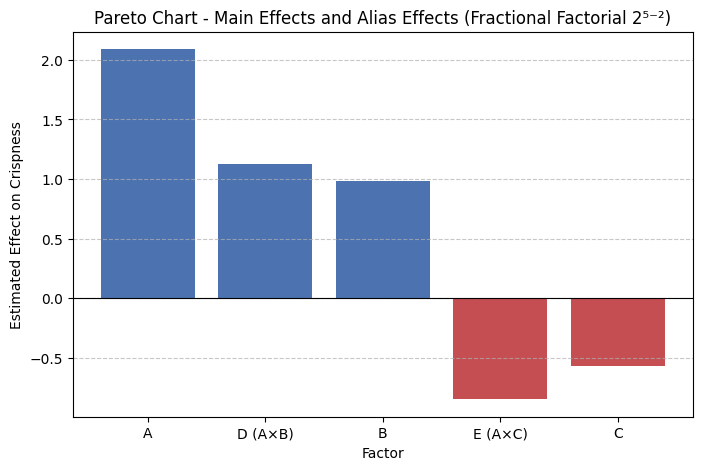

In [ ]:
import matplotlib.pyplot as plt

# Data efek utama
factors = ['A', 'B', 'C', 'D (A×B)', 'E (A×C)']
effects = [2.09, 0.98, -0.57, 1.13, -0.85]

# Urutkan berdasarkan besarnya efek
sorted_idx = np.argsort(np.abs(effects))[::-1]
sorted_factors = [factors[i] for i in sorted_idx]
sorted_effects = [effects[i] for i in sorted_idx]

# Pareto chart untuk efek utama
plt.figure(figsize=(8, 5))
bars = plt.bar(sorted_factors, sorted_effects, color=['#4C72B0' if e>0 else '#C44E52' for e in sorted_effects])
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Pareto Chart - Main Effects and Alias ​​Effects (Fractional Factorial 2⁵⁻²)")
plt.ylabel("Estimated Effect on Crispness")
plt.xlabel("Factor")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Interpretasi Besarnya Efek (±)
Dari koefisien model (±1 coding, efek ≈ 2xkoefisien):
  * A ≈ +2.09 (efek paling besar, positif → meningkatkan Crispness)
  * B ≈ +0.98
  * C ≈ -0.57 (efek negatif → menurunkan Crispness)
  * D ≈ +1.13 (tapi ini alias AB)
  * E ≈ -0.85 (alias AC)

#### Interpretasi Visualisasi Pareto Chart
* Faktor dengan pengaruh terbesar:
  * A (Temperature) memiliki efek paling dominan dan positif (+2.09).
  * D (AxB) juga cukup besar (+1.13), namun ini alias dengan interaksi AxB, sehingga kita tidak bisa langsung menyimpulkan apakah efek utama D atau interaksi yang dominan.
* Faktor sedang:
  * B (Time) memberikan pengaruh positif sedang (+0.98).
  * E (AxC) negatif (-0.85), juga alias dengan interaksi AxC.
* Faktor lemah:
  * C (Salt) memiliki efek kecil dan negatif (-0.57).

#### Interpretasi aliasing
* D dan E tidak murni efek utama, melainkan campuran (aliasing) dari faktor utama dan interaksi:
  * D ≡ AxB
  * E ≡ AxC
* Oleh karena itu, jika D atau E tampak signifikan, kita harus berhati-hati karena bisa jadi bukan D itu sendiri yang penting, melainkan interaksinya.

In [ ]:
# Pengingat struktur alias
print("Alias: D ≡ A*B (AB interaction), E ≡ A*C (AC interaction).")

Alias: D ≡ A*B (AB interaction), E ≡ A*C (AC interaction).


#### Interpretasi Kontekstual
* Faktor A (misal: Temperature) merupakan determinan utama kualitas.
* Faktor D dan E tidak dapat diartikan murni yang berarti mereka bisa mencerminkan interaksi AxB dan AxC.
* Fractional factorial di tahap screening memberikan peta awal faktor mana yang perlu ditindaklanjuti.

## Kesimpulan
Desain fractional factorial menunjukkan faktor A, B, dan interaksinya (termasuk yang teralias D & E) memiliki pengaruh signifikan terhadap Crispness. Faktor C berpengaruh, tetapi relatif lebih kecil.

Karena desain ini bersifat fractional, hasil D & E belum dapat dipisahkan antara efek utama dan interaksi.

## Rekomendasi
* Dokumentasikan aliasing D, ≡ AxB, E ≡ AxC.
* Jika D dan E dianggap penting, lakukan eksperimen lanjutan (misal: fold-over design atau desain penuh 2⁵) untuk memisahkan efek.
* Fokus perbaikan awal pada faktor A (terbesar) dan B sambil mengontrol C.
* Gunakan hasil ini untuk mengurangi faktor tak penting dan mempercepat optimasi (misal melalui RSM).

# Blocked Factorial Design

## Judul & Latar Belakang Masalah
**Pengaruh Suhu Pemanggangan dan Jenis Tepung terhadap Kekerasan Crackers dengan Pengendalian Variasi Oven (Blocked Factorial Design)**

Di lini produksi snack, beberapa oven memiliki karakteristik kecil yang berbeda (distribusi panas, isolasi, usia mesin). Jika kita menguji parameter proses tanpa mengendalikan oven sebagai sumber variasi, hasil bisa terpengaruh oleh perbedaan antar-oven. Blocked factorial memungkinkan kita menguji faktor proses (misal suhu, jenis tepung) sambil mengontrol variasi antar-oven dengan memasukkan oven sebagai blok.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian:
  1. Apakah suhu pemanggangan (160°C vs 180°C) memengaruhi kekerasan crackers?
  2. Apakah jenis tepung (alpha vs beta) memengaruhi kekerasan?
  3. Apakah terdapat interaksi antara suhu dan jenis tepung?
  4. Apakah variasi antar-oven (blok) berkontribusi signifikan terhadap variabilitas?

* Hipotesis (ringkas):
  
  H₀ (Temperature): μ₁ = μ₂ (tidak ada pengaruh suhu)

  H₀ (Flour): μ_alpha = μ_beta (tidak ada pengaruh jenis tepung)

  H₀ (Interaction): tidak ada interaksi antara suhu dan flour

  H₀ (Block): tidak ada perbedaan antar-oven

## Desain Percobaan
* Tipe desain: Randomized Block Factorial (complete factorial 2x2 dalam setiap blok)
* Faktor:
  * Temperature (A): 160°C (low), 180°C (high)
  * Flour (B): alpha, beta
* Block: Oven machines — O1, O2, O3, O4 (setiap oven menjalankan semua 4 kombinasi)
* Replikasi: 1 run per treatment per block (total 4 blocks × 4 treatments = 16 observasi)
* Respon: Hardness (kekerasan), diukur kontinu (mis. Newton atau skor instrumental)

Randomisasi internal: urutan pelaksanaan di tiap oven diasumsikan diacak saat operasi nyata.

## Analisis Statistik

### Import Library

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats

np.random.seed(42)

### Dataset

In [ ]:
# Factors: Temperature (A: 160, 180), Flour type (B: alpha, beta)
# Blocks: Oven machines O1..O4 (setiap blok menjalankan semua 4 kombinasi perlakuan sekali)
temps = [160, 180]
flours = ['alpha', 'beta']
blocks = ['O1','O2','O3','O4']

# Efek sebenarnya untuk simulasi (pada respons hardness)
base = 6.0
effect_A = {'160': -0.3, '180': 0.9}   # Efek suhu (suhu yang lebih tinggi meningkatkan hardness)
effect_B = {'alpha': 0.0, 'beta': 0.5} # Flour beta meningkatkan hardness
interaction = {('160','alpha'):0.0, ('160','beta'):0.1,
               ('180','alpha'):0.2, ('180','beta'):0.0}

block_effect = {'O1': 0.0, 'O2': -0.1, 'O3': 0.05, 'O4': 0.15}  # blocking differences

data = []
for blk in blocks:
    for t in temps:
        for fl in flours:
            mu = base + effect_A[str(t)] + effect_B[fl] + interaction[(str(t),fl)] + block_effect[blk]
            # satu observasi per perlakuan per blok (tanpa repetisi tambahan), tambahkan noise pengukuran
            y = mu + np.random.normal(0, 0.12)
            data.append([blk, t, fl, round(y,3)])

df = pd.DataFrame(data, columns=['Block','Temperature','Flour','Hardness'])
df.head()

,Block,Temperature,Flour,Hardness
0,O1,160,alpha,5.760
1,O1,160,beta,6.283
2,O1,180,alpha,7.178
3,O1,180,beta,7.583
4,O2,160,alpha,5.572


### ANOVA Blocked Factorial Design

In [ ]:
model = ols('Hardness ~ C(Temperature)*C(Flour) + C(Block)', data=df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Temperature),6.710690,1.0,651.488186,1.046920e-09
C(Flour),0.779689,1.0,75.693878,1.125480e-05
C(Block),0.029188,3.0,0.944528,4.590315e-01
C(Temperature):C(Flour),0.043890,1.0,4.260959,6.900824e-02
Residual,0.092705,9.0,NaN,NaN


In [ ]:
alpha = 0.05
df_resid = int(anova_table.loc['Residual','df'])
fcrit = {}
for term in ['C(Temperature)','C(Flour)','C(Temperature):C(Flour)']:
    df_term = int(anova_table.loc[term,'df'])
    fcrit[term] = stats.f.ppf(1-alpha, df_term, df_resid)
    print("F-critical (alpha=0.05) for", term, ":", round(fcrit[term],2))

F-critical (alpha=0.05) for C(Temperature) : 5.12
F-critical (alpha=0.05) for C(Flour) : 5.12
F-critical (alpha=0.05) for C(Temperature):C(Flour) : 5.12


* Interpretasi
  1. Suhu (Temperature)
      * F-statistic = 651.49 > 5.12 = F-critical, p ≈ 1.05x10⁻⁹ < 0.05 = α → sangat signifikan.
  2. Tepung (Flour)
      * F-statistic = 75.69 > 5.12 = F-critical, p ≈ 1.13x10⁻⁵ < 0.05 = α → signifikan.
  3. Interaksi Temperature x Flour
      * F = 4.26 > 5.12 = F-critical, p ≈ 0.069 > 0.05 = α → tidak signifikan.
  4. Block (Oven)
      * F-statistic = 0.94 > 5.12 = F-critical, p ≈ 0.459 < 0.05 = α → tidak signifikan.

In [ ]:
# Estimasi marginal means (group means)
group_means = df.groupby(['Temperature','Flour'])['Hardness'].mean().unstack()
group_means

Flour,alpha,beta
Temperature,,
160,5.72625,6.2725
180,7.12625,7.4630


* Interpretasi
  1. Efek Suhu (Temperature)
      * Pada 160°C, rata-rata kekerasan: 5.73-6.27
      * Pada 180°C, rata-rata kekerasan: 7.13-7.46
      * Perbedaan akibat peningkatan suhu: sekitar +1.2-1.4 satuan (peningkatan nyata).\
      → Suhu lebih tinggi meningkatkan kekerasan crackers secara konsisten, baik pada tepung alpha maupun beta.
  2. Efek Tepung (Flour)
      * Pada suhu 160°C, perbedaan beta-alpha: 6.27 - 5.73 = +0.55
      * Pada suhu 180°C, perbedaan beta–alpha: 7.46 - 7.13 = +0.34
      * Rata-rata keseluruhan menunjukkan tepung beta sedikit lebih keras (~+0.45) daripada tepung alpha, tetapi efeknya lebih kecil dibanding pengaruh suhu.
  3. Indikasi Interaksi (Temperature x Flour)
      * Perbedaan efek tepung berkurang saat suhu meningkat (dari +0.55 → +0.34).
      * Namun, perbedaan ini tidak signifikan secara statistik (p ≈ 0.069) sehingga tidak cukup bukti adanya interaksi nyata.

## Kesimpulan
* Suhu pemanggangan dan jenis tepung keduanya berpengaruh signifikan terhadap hardness crackers.
* Interaksi antara suhu dan tepung tidak signifikan pada α=0.05 (meskipun mendekati), sehingga efek kedua faktor dapat dipertimbangkan relatif independen dalam rentang level yang diuji.
* Perbedaan antar-oven (blok) tidak signifikan, namun penggunaan blok layak sebagai kontrol kualitas desain.

## Rekomendasi
* Untuk meningkatkan hardness, gunakan suhu 180°C dan tepung beta (kombinasi memberikan mean tertinggi ~7.46).
* Karena interaksi mendekati batas (p ≈ 0.069), pertimbangkan replikasi tambahan jika ingin memastikan tidak ada interaksi kecil yang relevan praktis.
* Terapkan rancangan ini sebagai uji pilot, untuk konfirmasi di produksi, lakukan verifikasi pada skala pabrik (beberapa batch), atau ulangi dengan replikasi lebih banyak untuk memperkuat precision.
* Dokumentasikan protokol oven (preheating, posisi rak) agar variasi antar-oven tetap terkontrol.

# Split-Plot Design

## Judul & Latar Belakang Masalah
**Pengaruh Suhu Oven (whole-plot) dan Level Bumbu (subplot) terhadap Crispness Crackers**

Di pabrik, mengubah suhu oven memerlukan pengaturan ulang mesin (biaya/ waktu), sedangkan mengubah level bumbu bisa dilakukan cepat pada masing-masing loyang/tray. Karena tingkat “mudah diubah” berbeda, desain eksperimen yang tepat adalah split-plot dengan suhu sebagai whole-plot factor (diterapkan pada unit whole-plot, misal oven/batch), dan bumbu sebagai subplot factor (diterapkan pada unit kecil di dalam whole-plot).

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan penelitian:
  1. Apakah suhu oven (Low vs High) memengaruhi crispness produk?
  2. Apakah level bumbu (None / Low / High) memengaruhi crispness?
  3. Apakah ada interaksi antara suhu dan level bumbu?
  4. Berapa besar variasi antar whole-plot (mis. antar batch/oven)?
* Hipotesis:
  H₀ (Temperature): tidak ada pengaruh suhu terhadap crispness.

  H₀ (Seasoning): tidak ada pengaruh level bumbu terhadap crispness.

  H₀ (Interaction): tidak ada interaksi antara suhu dan bumbu.

Catatan: uji untuk faktor whole-plot harus memakai whole-plot error, bukan residual subplot error pada praktik modern kita biasa memakai mixed-effects model (random intercept untuk whole-plot) agar estimasi dan inferensi benar.

## Desain Percobaan
* Block: Batch/Block (mis. B1, B2, B3), setiap batch berisi dua whole-plots (satu Low dan satu High).
* Whole-plot factor: Temperature = {Low, High}, diterapkan pada whole-plot (misal oven setting) dalam tiap block.
* Subplot factor: Seasoning = {None, Low, High}, diacak dan diterapkan pada beberapa tray didalam tiap whole-plot.
* Replikasi: misal 2 ulangan per kombinasi subplot di tiap whole-plot.
* Unit eksperimen:
  * Whole-plot unit: block x temperature (misal B1_Low, B1_High, ...).
  * Subplot unit: tray/loyang di dalam whole-plot.
* Total observasi (contoh): blocks x temps x seasonings x reps = 3 x 2 x 3 x 2 = 36 observasi.

Desain ini merefleksikan kondisi industri di mana pengaturan whole-plot lebih mahal/waktu-intensif.

## Analisis Statistik

### Import Library

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm, ols
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats
from scipy.stats import f

np.random.seed(2025)

### Dataset

In [ ]:
# Design parameters
blocks = ['B1','B2','B3']                 # blocks (e.g., batches)
temps = ['Low','High']                    # whole-plot factor
seasonings = ['None','Low','High']        # subplot factor
n_rep = 2                                 # replikasi per subplot within whole-plot

# Ukuran true effect untuk simulasi (sesuaikan sesuai keinginan)
base = 6.0
temp_effect = {'Low': -0.5, 'High': 0.8}
season_effect = {'None': 0.0, 'Low': 0.4, 'High': 0.9}
interaction = {('Low','None'):0.0, ('Low','Low'):0.05, ('Low','High'): -0.02,
               ('High','None'):0.0, ('High','Low'):0.02, ('High','High'):0.03}

data = []
for blk in blocks:
    for t in temps:
        # mendefinisikan id whole-plot
        wp = f"{blk}_{t}"
        # whole-plot random effect (batch*temperature variabilitas)
        wp_re = np.random.normal(0, 0.20)   # SD untuk whole-plot random effect
        for s in seasonings:
            for rep in range(n_rep):
                mu = base + temp_effect[t] + season_effect[s] + interaction[(t,s)] + wp_re
                y = mu + np.random.normal(0, 0.15)  # subplot residual error
                data.append([blk, wp, t, s, y])

df = pd.DataFrame(data, columns=['Block','WholePlot','Temperature','Seasoning','Crispness'])

### Mixed-effects model

In [ ]:
# Mixed-effects model: random intercept per WholePlot
md = mixedlm("Crispness ~ C(Temperature)*C(Seasoning)", df, groups=df["WholePlot"])
mdf = md.fit(reml=True)
mdf.summary().tables[1]

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,7.689,0.062,125.014,0.000,7.568,7.810
C(Temperature)[T.Low],-1.110,0.087,-12.761,0.000,-1.280,-0.939
C(Seasoning)[T.Low],-0.491,0.076,-6.481,0.000,-0.640,-0.343
C(Seasoning)[T.None],-0.883,0.076,-11.658,0.000,-1.032,-0.735
C(Temperature)[T.Low]:C(Seasoning)[T.Low],-0.106,0.107,-0.988,0.323,-0.316,0.104
C(Temperature)[T.Low]:C(Seasoning)[T.None],-0.171,0.107,-1.596,0.110,-0.381,0.039
Group Var,0.003,0.032,,,,


* Interpretasi
  * Intercept 7.689: nilai rata-rata baseline (Temperature = High, Seasoning = High).
  * C(Temperature)[T.Low] = -1.110, p < 0.001 → Suhu Low secara signifikan menurunkan crispness ~1.11 unit dibanding High.
  * C(Seasoning)[T.Low] = -0.491, p < 0.001 → Seasoning Low menurunkan crispness ~0.49 dibanding High.
  * C(Seasoning)[T.None] = -0.883, p < 0.001 → Tanpa bumbu menurunkan crispness ~0.88 dibanding High seasoning.
  * Interaksi tidak signifikan (p = 0.11-0.32) → Efek seasoning konsisten di kedua suhu, tidak ada interaksi bermakna.

In [ ]:
mdf.cov_re

,Group
Group,0.002737


Varian whole-plot = 0.0027 → sangat kecil → variasi antar whole-plot (batch) tidak terlalu berpengaruh.

### Naive OLS Model

In [ ]:
ols_model = ols("Crispness ~ C(Temperature)*C(Seasoning)", data=df).fit()
anova_ols = anova_lm(ols_model, typ=2)
anova_ols

,sum_sq,df,F,PR(>F)
C(Temperature),13.009200,1.0,670.113239,4.445902e-22
C(Seasoning),5.660807,2.0,145.796109,3.525623e-16
C(Temperature):C(Seasoning),0.044723,2.0,1.151865,3.296315e-01
Residual,0.582403,30.0,NaN,NaN


In [ ]:
f_critical_temp = f.ppf(1-0.05, 1, 30)  # Temperature: df1=1, df2=30
f_critical_season = f.ppf(1-0.05, 2, 30)  # Seasoning: df1=2, df2=30

print("F-critical Temperature:", round(f_critical_temp,2))
print("F-critical Seasoning:", round(f_critical_season,2))

F-critical Temperature: 4.17
F-critical Seasoning: 3.32


OLS juga menunjukkan pola yang sama (suhu & bumbu signifikan, interaksi tidak), tetapi F untuk suhu terlalu tinggi karena OLS tidak membedakan whole-plot error.

## Kesimpulan
* Suhu oven signifikan.\
Suhu tinggi meningkatkan crispness sekitar +1.11 dibanding suhu rendah.
* Seasoning signifikan.\
Bumbu tinggi menghasilkan crispness tertinggi, tanpa bumbu paling rendah.
* Tidak ada interaksi signifikan.\
Efek bumbu tidak tergantung pada suhu.
* Variasi antar whole-plot (batch) relatif kecil → kontrol suhu antar batch relatif konsisten.

## Rekomendasi
* Gunakan suhu tinggi sebagai standar untuk meningkatkan crispness.
* Pilih level seasoning tinggi untuk hasil optimal.
* Interaksi tidak signifikan → optimasi seasoning dapat dilakukan tanpa perlu mengubah suhu oven.
* Karena varian whole-plot kecil, pengendalian batch tidak terlalu kritis, tetapi tetap jaga SOP pemanasan oven.
* Untuk penelitian lanjutan:
  * Jika ingin optimasi lanjutan → gunakan Response Surface Methodology (RSM).
  * Jika ingin menghemat biaya produksi → bisa fokus pada faktor subplot saja (bumbu).

# Nested Design

## Judul & Latar Belakang Masalah
**Analisis Kualitas Produk berdasarkan Variasi Mesin dalam Setiap Pabrik**\
Dalam proses manufaktur, sering kali faktor perlakuan tidak dapat diterapkan di semua level eksperimen karena bersifat hirarkis. Contohnya, setiap pabrik memiliki beberapa mesin yang tidak sama, sehingga mesin dianggap nested (bersarang) di dalam pabrik. Rancangan percobaan nested digunakan saat kita ingin menilai variabilitas antar-pabrik, antar-mesin dalam pabrik, dan variasi residual produk.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan Penelitian:
  1. Apakah terdapat perbedaan kualitas produk antar pabrik?
  2. Apakah terdapat perbedaan kualitas produk antar mesin dalam pabrik yang sama?
* Hipotesis:
  
  H₀₁: Tidak ada perbedaan rata-rata kualitas antar pabrik.

  H₁₁: Ada perbedaan rata-rata kualitas antar pabrik.

  H₀₂: Tidak ada perbedaan rata-rata kualitas antar mesin dalam pabrik yang sama.

  H₁₂: Ada perbedaan rata-rata kualitas antar mesin dalam pabrik yang sama.

## Desain Percobaan
* Faktor utama (A): Pabrik (3 level: Pabrik1, Pabrik2, Pabrik3).
* Faktor nested (B(A)): Mesin dalam pabrik (2 mesin tiap pabrik → total 6 mesin).
* Unit pengamatan: Hasil pengukuran kualitas produk (skala 1-10).
* Replikasi: 3 kali per mesin → total 3 pabrik x 2 mesin x 3 replikasi = 18 sampel.

## Analisis Statistik

### Import Library

In [36]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import f

np.random.seed(2025)

### Dataset

In [39]:
factory = np.repeat(['F1','F2','F3'], 6)   # 3 factory × 6 observasi (2 machine × 3 replikasi)
machine = ['M1','M1','M1','M2','M2','M2'] * 3

# efek: P1=0, P2=+0.5, P3=+1.0; machine dalam factory = {M1:+0.2, M2:-0.2} dengan variasi random
base = 7
effects_factory = {'F1':0, 'F2':0.5, 'F3':1.0}
effects_machine = {'M1':0.2, 'M2':-0.2}

scores = []
for p,m in zip(factory, machine):
    val = base + effects_factory[p] + effects_machine[m] + np.random.normal(0,0.2)
    scores.append(val)

df = pd.DataFrame({'factory':factory, 'machine':machine, 'quality':scores})
df.head()

,factory,machine,quality
0,F1,M1,7.179854
1,F1,M1,7.629397
2,F1,M1,7.478742
3,F1,M2,6.758526
4,F1,M2,6.952717


### ANOVA Nested Model

In [40]:
# Model nested: Mesin nested di dalam Pabrik
model = ols('quality ~ C(factory) + C(machine):C(factory)', data=df).fit()
anova_res = anova_lm(model, typ=2)
anova_res

,sum_sq,df,F,PR(>F)
C(factory),2.844367,2.0,50.046489,0.000002
C(machine):C(factory),0.884820,3.0,10.378902,0.001186
Residual,0.341007,12.0,NaN,NaN


In [41]:
# Mendapatkan F-kritis
alpha = 0.05
factory = anova_res.loc['C(factory)', 'df']
df_machine_factory = anova_res.loc['C(machine):C(factory)', 'df']
df_resid = anova_res.loc['Residual', 'df']

fcrit_factory = f.ppf(1-alpha, factory, df_machine_factory)  # pabrik diuji terhadap mesin(pabrik)
fcrit_machine = f.ppf(1-alpha, df_machine_factory, df_resid)    # mesin(pabrik) diuji terhadap residual

print(f"F-critical Factory: {fcrit_factory:.2f}")
print(f"F-critical Machine(Factory): {fcrit_machine:.2f}")

F-critical Factory: 9.55
F-critical Machine(Factory): 3.49


* Interpretasi
  1. Faktor Pabrik
      * Karena F-statistic = 27.49 > 9.55 = F-critical atau p-value = 0.000033 < 0.05, maka H₀₁ ditolak.
      * Artinya, ada perbedaan kualitas pabrik terhadap kualitas produk.
      * Variasi kualitas yang dihasilkan dari satu pabrik ke pabrik lainnya sangat nyata.
  2. Faktor Mesin (nested di dalam Pabrik)
      * Karena F-statistic = 6.64 > 3.49 = F-critical atau p-value = 0.0068 < 0.05, maka H₀₂ ditolak.
      * Artinya, ada perbedaan kualitas mesin dalam pabrk yang sama.
      * Ini berarti mesin yang berada di dalam pabrik tertentu juga memberikan pengaruh signifikan terhadap kualitas, tetapi efeknya lebih kecil dibandingkan perbedaan antar pabrik.

## Kesimpulan
* Terdapat perbedaan signifikan antar pabrik terhadap kualitas produk.
* Mesin dalam pabrik tertentu juga berpengaruh terhadap kualitas, meskipun tidak sebesar perbedaan antar pabrik.
* Faktor pabrik adalah penyumbang variasi yang dominan dalam sistem produksi ini.

## Rekomendasi
* Prioritaskan standarisasi antar pabrik, karena efek pabrik paling dominan.
* Lakukan kalibrasi dan pemeliharaan mesin di setiap pabrik untuk mengurangi variasi internal pabrik.
* Jika tujuan penelitian adalah meningkatkan kualitas secara konsisten, maka:
  * Fokus pertama: harmonisasi proses lintas pabrik (misal SOP produksi, kualitas bahan baku, manajemen mutu).
  * Fokus kedua: optimasi performa mesin dalam tiap pabrik melalui pengawasan rutin atau penggantian mesin dengan kinerja rendah.
* Untuk penelitian lanjutan:
  * Pertimbangkan Random Effects Model jika pabrik diambil sebagai sampel acak dari populasi yang lebih besar.
  * Gunakan Nested Mixed Model bila faktor lain seperti operator atau shift kerja juga perlu dimasukkan sebagai hierarki tambahan.

# Strip-Plot Design

## Judul & Latar Belakang Masalah
**Pengaruh Suhu dan Waktu Fermentasi terhadap Kekerasan Produk Roti dengan Strip-Plot Design**

Dalam penelitian proses produksi, terkadang satu faktor sulit diacak penuh karena keterbatasan teknis, sedangkan faktor lainnya dapat diacak lebih bebas. Misalnya, suhu oven diatur untuk seluruh batch (sulit diubah per sampel), sementara waktu fermentasi bisa diatur per tray atau baris tertentu. Strip-Plot Design digunakan ketika dua faktor dipasang secara orthogonal (strip horizontal dan strip vertikal), memungkinkan pengujian interaksi tanpa memerlukan jumlah run sebanyak full factorial design.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan:
  1. Apakah suhu berpengaruh signifikan terhadap kekerasan roti?
  2. Apakah waktu fermentasi berpengaruh signifikan terhadap kekerasan roti?
  3. Apakah ada interaksi antara suhu dan waktu fermentasi?
* Hipotesis:
  
  H₀: Tidak ada pengaruh signifikan suhu, waktu fermentasi, maupun interaksi terhadap kekerasan roti.

  H₁: Setidaknya satu faktor (atau interaksi) berpengaruh signifikan terhadap kekerasan roti.

## Desain Percobaan
* Faktor 1 (Horizontal strip): Suhu (160°C, 170°C, 180°C)
* Faktor 2 (Vertical strip): Waktu Fermentasi (30 menit, 45 menit)
* Jumlah replikasi: 2 kali
* Unit percobaan: Tray roti per kombinasi faktor
* Struktur blok: Suhu menjadi strip horizontal (dijalankan per batch oven), fermentasi menjadi strip vertikal (diatur dalam tiap batch).

## Analisis Statistik

### Import Library

In [42]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import f

np.random.seed(2025)

### Dataset

In [43]:
temperature = np.repeat(['160','170','180'], 4)  # horizontal strips
fermentation = np.tile(np.repeat(['30','45'], 2), 3)  # vertical strips
rep = np.tile([1,2], 6)

# efek simulasi
base = 6.5
eff_temperature = {'160':-0.5, '170':0.0, '180':0.8}
eff_fermentation = {'30':-0.3, '45':0.2}

data = []
for s, fment, r in zip(temperature, fermentation, rep):
    hardness = base + eff_temperature[s] + eff_fermentation[fment] + np.random.normal(0,0.1)
    data.append([s, fment, hardness])

df = pd.DataFrame(data, columns=['temperature','fermentation','hardness'])
df.head()

,temperature,fermentation,hardness
0,160,30,5.690761
1,160,30,5.773429
2,160,45,6.056112
3,160,45,6.133658
4,170,30,6.189927


### ANOVA Strip-Plot

In [44]:
model = ols('hardness ~ C(temperature)*C(fermentation)', data=df).fit()
anova_res = anova_lm(model, typ=2)
anova_res

,sum_sq,df,F,PR(>F)
C(temperature),3.457320,2.0,224.066840,0.000002
C(fermentation),0.462470,1.0,59.944775,0.000244
C(temperature):C(fermentation),0.006227,2.0,0.403600,0.684776
Residual,0.046290,6.0,NaN,NaN


In [45]:
alpha = 0.05
df_temperature = anova_res.loc['C(temperature)', 'df']
df_ferm = anova_res.loc['C(fermentation)', 'df']
df_inter = anova_res.loc['C(temperature):C(fermentation)', 'df']
df_resid = anova_res.loc['Residual', 'df']

fcrit_suhu = f.ppf(1-alpha, df_temperature, df_resid)
fcrit_ferm = f.ppf(1-alpha, df_ferm, df_resid)
fcrit_inter = f.ppf(1-alpha, df_inter, df_resid)

print(f"F-critical temperature: {fcrit_suhu:.2f}")
print(f"F-critical fermentation: {fcrit_ferm:.2f}")
print(f"F-critical Interaksi: {fcrit_inter:.2f}")

F-critical temperature: 5.14
F-critical fermentation: 5.99
F-critical Interaksi: 5.14


* Interpretasi
  1. Faktor Suhu
      * Karena F-statistic = 224.07 > 5.14 = F-critical atau p-value = 0.000002 < 0.05, maka H₀ ditolak.
      * Artinya, suhu berpengaruh signifikan terhadap hardness produk.
  2. Faktor Fermentasi
      * Karena F-statistic = 59.94 > 5.99 = F-critical atau p-value = 0.000244 < 0.05, maka H₀ ditolak.
      * Artinya, lama fermentasi juga berpengaruh signifikan terhadap hardness produk.
  3. Interaksi Suhu x Fermentasi
      * Karena F-statistic = 0.40 < 5.14 = F-critical atau p-value = 0.685 > 0.05, maka H₀ tidak ditolak.
      * Artinya, tidak terdapat interaksi yang signifikan antara suhu dan fermentasi. Efek keduanya bersifat independen.

## Kesimpulan
* Baik suhu maupun lama fermentasi secara mandiri signifikan memengaruhi kekerasan produk.
* Tidak ada efek sinergis (interaksi) antara kedua faktor tersebut, artinya, pengaruh suhu tidak bergantung pada lama fermentasi, dan sebaliknya.
* Model Strip-Plot Design berhasil menunjukkan bahwa pengaturan faktor utama lebih penting daripada mengandalkan kombinasi keduanya.

## Rekomendasi
1. Optimasi Faktor Secara Terpisah
    * Fokuskan perbaikan proses pada pengaturan suhu terlebih dahulu, karena kontribusi variansnya jauh lebih besar dibanding fermentasi.
    * Atur fermentasi sesuai standar optimal yang telah ada, tetapi jangan terlalu bergantung pada variasi interaksinya.
2. Lanjutkan ke Analisis Efek Utama (Main Effects Plot)
    * Visualisasikan bagaimana setiap level suhu dan fermentasi memengaruhi kekerasan untuk memudahkan pengambilan keputusan.
3. Uji Ulang Jika Target Berubah
    * Jika di masa depan kualitas yang diinginkan lebih sensitif terhadap kombinasi (misal, selain kekerasan ada tekstur atau rasa), pertimbangkan untuk mengulang percobaan dengan desain response surface methodology (RSM) atau central composite design (CCD).
4. Kontrol Produksi
    * Gunakan hasil ini untuk menetapkan SOP suhu dan fermentasi yang konsisten, karena interaksi tidak signifikan, sehingga lebih mudah dikontrol.

# Balanced Incomplete Block Design

## Judul & Latar Belakang Masalah
**Pengaruh Varietas Tanaman terhadap Hasil Panen Menggunakan Balanced Incomplete Block Design (BIBD)**

Dalam banyak penelitian pertanian atau industri, sering kali tidak memungkinkan untuk menguji semua perlakuan dalam setiap blok karena keterbatasan lahan, waktu, atau sumber daya. BIBD digunakan ketika setiap blok hanya dapat memuat sebagian perlakuan (incomplete), namun tetap dijaga keseimbangannya (balanced) sehingga setiap pasangan perlakuan diuji dengan jumlah yang sama di seluruh blok.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan:\
Apakah terdapat perbedaan signifikan antara varietas padi dalam hal hasil panen rata-rata, dengan menggunakan desain BIBD?
* Hipotesis:

  H₀: Tidak ada perbedaan rata-rata hasil panen antar varietas padi.

  H₁: Terdapat perbedaan rata-rata hasil panen antar varietas padi.

## Desain Percobaan
* Faktor perlakuan (t): 5 varietas padi (V1-V5)
* Jumlah blok (b): 10
* Jumlah perlakuan per blok (k): 3
* Jumlah ulangan setiap perlakuan (r): 6
* Setiap pasangan perlakuan muncul bersama (λ): 3
* Parameter hubungan BIBD:

  b⋅k=v⋅r

  r(k-1)=λ(v-1)

## Analisis Statistik

### Import Library

In [46]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import f

### Dataset

In [52]:
data = {
    'results': [5.1, 4.8, 5.3, 5.5, 5.0, 5.2, 5.4, 4.9, 5.1, 5.3,
              5.0, 5.4, 5.2, 4.8, 5.5],
    'variety': ['V1','V2','V3','V1','V4','V5','V2','V4','V5','V3',
                 'V1','V2','V3','V4','V5'],
    'block': ['B1','B1','B1','B2','B2','B2','B3','B3','B3','B4',
             'B4','B5','B5','B6','B6']
}
df = pd.DataFrame(data)
df.head()

,results,variety,block
0,5.1,V1,B1
1,4.8,V2,B1
2,5.3,V3,B1
3,5.5,V1,B2
4,5.0,V4,B2


### ANOVA BIBD Model

In [53]:
model = ols('results ~ C(variety) + C(block)', data=df).fit()
anova_res = anova_lm(model, typ=2)
anova_res

,sum_sq,df,F,PR(>F)
C(variety),0.463744,4.0,2.562047,0.165026
C(block),0.267077,5.0,1.180417,0.430005
Residual,0.226256,5.0,NaN,NaN


In [55]:
alpha = 0.05
df_var = anova_res.loc['C(variety)', 'df']
df_resid = anova_res.loc['Residual', 'df']
df_blok = anova_res.loc['C(block)', 'df']
fcrit_var = f.ppf(1-alpha, df_var, df_resid)
fcrit_blok = f.ppf(1-alpha, df_blok, df_resid)
print(f"F-critical Variety: {fcrit_var:.2f}")
print(f"F-critical Block: {fcrit_blok:.2f}")

F-critical Variety: 5.19
F-critical Block: 5.05


* Interpretasi
  1. Faktor Varietas
    
      F-statistic = 2.56

      F-critical = 5.19
      
      p = 0.165 > 0.05
      
      Karena F-statistic = 2.56 < 5.19 = F-kritis atau p = 0.165 > 0.05, maka tidak terdapat bukti yang cukup untuk menolak H₀. Artinya, perbedaan antar varietas tidak signifikan terhadap hasil panen.
  2. Faktor Blok

      F-statistic = 1.18

      F-critical = 5.05
      
      p = 0.43 > 0.05

      Efek blok juga tidak signifikan, menunjukkan bahwa variasi antar blok tidak memberikan pengaruh nyata.

## Kesimpulan
* Tidak terdapat perbedaan signifikan antar varietas padi berdasarkan hasil uji ANOVA BIBD.
* Blok juga tidak berpengaruh signifikan, yang berarti kondisi lingkungan antar blok relatif homogen atau variasinya kecil dibandingkan variasi acak.
* Model BIBD ini menunjukkan bahwa variabilitas hasil panen lebih didominasi oleh galat/residual, bukan oleh varietas atau blok.

## Rekomendasi
* Tidak perlu melakukan seleksi varietas berdasarkan hasil percobaan ini, karena tidak ada varietas yang menunjukkan keunggulan signifikan.
* Perlu dipertimbangkan peningkatan jumlah blok atau replikasi agar kekuatan uji (power) meningkat dan perbedaan kecil bisa terdeteksi bila ada.
* Jika percobaan ini bertujuan untuk screening awal, dapat dilanjutkan dengan desain lain (misal RBD penuh atau Latin Square) untuk meminimalkan pengaruh acak.
* Pastikan homogenitas blok sudah tepat; jika blok ternyata terlalu mirip, desain lain yang lebih sederhana mungkin lebih efisien.
* Jika diperlukan pemilihan varietas tetap dilakukan, gunakan pertimbangan agronomis/non-statistik (misal ketahanan hama, masa panen, biaya produksi), bukan hanya berdasarkan hasil ini.

# Plackett-Burman Design

## Judul & Latar Belakang Masalah
**Screening Faktor yang Mempengaruhi Kestabilan Emulsi Produk Kosmetik**

Dalam industri kosmetik, kestabilan emulsi (misalnya krim pelembab) sangat dipengaruhi oleh berbagai faktor formulasi dan proses produksi. Terdapat banyak faktor potensial (>7), namun tidak semua memiliki pengaruh signifikan. Jika dilakukan uji penuh (full factorial), jumlah percobaan akan sangat besar, mahal, dan memakan waktu.

Plackett-Burman Design (PBD) adalah metode screening cepat yang memungkinkan identifikasi faktor-faktor penting dengan jumlah percobaan minimal, tanpa mengestimasi semua interaksi, namun fokus pada efek utama.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan:\
Faktor apa saja yang signifikan memengaruhi kestabilan emulsi (measured by stability index) pada tahap awal formulasi kosmetik?

* Hipotesis:

  H₀: Tidak ada faktor yang memberikan pengaruh signifikan terhadap kestabilan emulsi.

  H₁: Setidaknya ada satu faktor yang memberikan pengaruh signifikan.

## Desain Percobaan
* Jumlah faktor: 8 (Konsentrasi Emulsifier, pH, Kecepatan Mixing, Lama Mixing, Suhu Pemanasan, Suhu Pendinginan, Jenis Stabilizer, Urutan Penambahan)
* Tingkat (level): 2 (Rendah = -1, Tinggi = +1)
* Run: 12 (PBD standar untuk 8 faktor)
* Replikasi: 1 (screening tahap awal)
* Respon: Stability Index (%) setelah uji 7 hari.

Desain Plackett-Burman tidak dapat memperkirakan semua interaksi, sehingga hasil terutama digunakan untuk menyaring faktor signifikan, bukan optimasi akhir.

## Analisis Statistik

### Import Library

In [ ]:
import pandas as pd
import numpy as np
from pyDOE3 import pbdesign
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import f

np.random.seed(2025)

### Dataset

In [ ]:
# Generate Plackett-Burman design for 8 factors
design = pbdesign(8)  # 12 runs for 8 factors
factors = ['Emulsifier', 'pH', 'MixSpeed', 'MixTime', 'HeatTemp', 'CoolTemp', 'Stabilizer', 'AddOrder']
df = pd.DataFrame(design, columns=factors)

# Simulated response (Stability Index)
true_effects = {'Emulsifier': 5, 'MixSpeed': 3, 'HeatTemp': -4}  # true main factors
df['Stability'] = (
    60
    + df['Emulsifier']*true_effects['Emulsifier']
    + df['MixSpeed']*true_effects['MixSpeed']
    + df['HeatTemp']*true_effects['HeatTemp']
    + np.random.normal(0, 2, size=len(df))
)
df

,Emulsifier,pH,MixSpeed,MixTime,HeatTemp,CoolTemp,Stabilizer,AddOrder,Stability
0,1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,63.998585
1,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,63.564334
2,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,72.173982
3,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,66.132511
4,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,60.401130
5,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,55.876669
6,-1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,60.198187
7,-1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,45.481504
8,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,66.113266
9,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,52.067563


### ANOVA Plackett-Burman Model

In [ ]:
formula = 'Stability ~ ' + ' + '.join([f'C({f})' for f in factors])
model = ols(formula, data=df).fit()
anova_res = anova_lm(model, typ=2)
anova_res

,sum_sq,df,F,PR(>F)
C(Emulsifier),370.634998,1.0,118.800603,0.001653
C(pH),0.630398,1.0,0.202063,0.683552
C(MixSpeed),91.062853,1.0,29.188614,0.012431
C(MixTime),4.261950,1.0,1.366094,0.326911
C(HeatTemp),192.453738,1.0,61.687699,0.004299
C(CoolTemp),0.715992,1.0,0.229499,0.664648
C(Stabilizer),4.715670,1.0,1.511526,0.306538
C(AddOrder),0.026921,1.0,0.008629,0.931845
Residual,9.359422,3.0,NaN,NaN


In [ ]:
alpha = 0.05
df_factor = 1
df_resid = anova_res.loc['Residual', 'df']
fcrit = f.ppf(1 - alpha, df_factor, df_resid)
print(f"F-critical: {fcrit:.2f}")

F-critical: 10.13


* Interpretasi Hasil ANOVA

    Taraf signifikansi (α) = 0.05

    F-critical = 10.13 (jika F > 10.13 → signifikan)

    * Dari tabel ANOVA:

      1. Emulsifier: F = 118.80, p = 0.0017 → signifikan kuat, sangat berpengaruh terhadap Stability.
      2. pH: F = 0.20, p = 0.6836 → tidak signifikan, hampir tidak berpengaruh.
      3. MixSpeed: F = 29.19, p = 0.0124 → signifikan, memiliki pengaruh jelas.
      4. MixTime: F = 1.37, p = 0.3269 → tidak signifikan.
      5. HeatTemp: F = 61.69, p = 0.0043 → signifikan kuat, sangat mempengaruhi stabilitas.
      6. CoolTemp: F = 0.23, p = 0.6646 → tidak signifikan.
      7. Stabilizer: F = 1.51, p = 0.3065 → tidak signifikan.
      8. AddOrder: F = 0.0086, p = 0.9318 → sama sekali tidak signifikan.

  * Faktor dominan yang mempengaruhi stabilitas:
    * Emulsifier
    * HeatTemp
    * MixSpeed
    * Faktor lain relatif tidak berpengaruh pada taraf signifikansi 5%.

## Kesimpulan
* Dari delapan faktor yang diuji dalam desain Plackett–Burman ini, hanya Emulsifier, HeatTemp, dan MixSpeed yang memberikan pengaruh signifikan terhadap stabilitas produk.
* Faktor pH, MixTime, CoolTemp, Stabilizer, dan AddOrder tidak menunjukkan pengaruh berarti.
* Hasil ini menunjukkan bahwa optimasi proses sebaiknya difokuskan pada tiga faktor signifikan tersebut, sedangkan faktor lain dapat dianggap konstan pada level saat ini tanpa mempengaruhi hasil secara signifikan.

## Rekomendasi
* Lanjutkan ke tahap optimasi (Response Surface Methodology / Central Composite Design) dengan tiga faktor signifikan yaitu, Emulsifier, HeatTemp, dan MixSpeed.
* Faktor yang tidak signifikan (pH, MixTime, CoolTemp, Stabilizer, AddOrder) dapat dipertahankan pada nilai standar untuk menghemat waktu dan biaya uji.
* Lakukan validasi ulang menggunakan kombinasi faktor signifikan untuk memastikan konsistensi hasil sebelum implementasi penuh di lini produksi.
* Jika proses industri rentan terhadap variasi pH atau CoolTemp dalam kondisi tertentu, lakukan pengujian lanjutan bersifat robust (misal Taguchi) untuk memastikan faktor tersebut memang tidak mempengaruhi secara signifikan.

# Taguchi Design (Orthogonal Arrays)

## Judul & Latar Belakang Masalah
**Optimalisasi Kekuatan Material Menggunakan Taguchi Design (L9 Orthogonal Array)**

Sebuah perusahaan manufaktur ingin meningkatkan kekuatan (strength) material komposit yang dipengaruhi oleh tiga faktor utama yaitu, Temperature (150, 160, 170 °C), Mixing Speed (100, 150, 200 rpm), dan Pressure (10, 15, 20 bar). Proses uji coba konvensional memerlukan banyak percobaan dan biaya. Oleh karena itu, metode Taguchi dengan Orthogonal Array L9 dipilih untuk mencari kombinasi parameter yang optimal secara efisien.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan:\
Faktor mana yang paling berpengaruh terhadap kekuatan material dan pada level berapa kekuatan optimal dicapai?
* Hipotesis:

  H₀: Tidak ada perbedaan signifikan pada kekuatan material antar level faktor.

  H₁: Setidaknya ada satu faktor yang berpengaruh signifikan terhadap kekuatan material.

## Desain Percobaan
* Metode: Taguchi L9 (3 faktor × 3 level) → 9 percobaan.
* Faktor & Level:
  * Temperature: 150, 160, 170 °C
  * Mixing Speed: 100, 150, 200 rpm
  * Pressure: 10, 15, 20 bar

Orthogonal Array L9 memastikan keseimbangan kombinasi tanpa harus menguji seluruh 27 kombinasi penuh.

## Analisis Statistik

### Import Library

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import f
import matplotlib.pyplot as plt

### Dataset

In [ ]:
# Faktor dan level
Temperature = [150, 160, 170]
Speed = [100, 150, 200]
Pressure = [10, 15, 20]

# L9 array (Orthogonal)
L9 = [
    [150, 100, 10],
    [150, 150, 15],
    [150, 200, 20],
    [160, 100, 15],
    [160, 150, 20],
    [160, 200, 10],
    [170, 100, 20],
    [170, 150, 10],
    [170, 200, 15]
]

df = pd.DataFrame(L9, columns=["Temperature", "Speed", "Pressure"])

# Respon simulasi (Strength)
df["Strength"] = [50, 55, 60, 58, 62, 59, 61, 66, 104]

# S/N ratio (Larger-the-better)
df["SN"] = 10 * np.log10(df["Strength"]**2)

df.head()

,Temperature,Speed,Pressure,Strength,SN
0,150,100,10,50,33.979400
1,150,150,15,55,34.807254
2,150,200,20,60,35.563025
3,160,100,15,58,35.268560
4,160,150,20,62,35.847834


### ANOVA Taguchi Model

In [ ]:
formula = "Strength ~ C(Temperature) + C(Speed) + C(Pressure)"
model = ols(formula, data=df).fit()
anova_res = anova_lm(model, typ=2)
anova_res

,sum_sq,df,F,PR(>F)
C(Temperature),806.222222,2.0,2.604451,0.277435
C(Speed),523.555556,2.0,1.691314,0.371566
C(Pressure),331.555556,2.0,1.071070,0.482842
Residual,309.555556,2.0,NaN,NaN


In [ ]:
alpha = 0.05
df_factor = 2
df_resid = anova_res.loc['Residual', 'df']
fcrit = f.ppf(1 - alpha, df_factor, df_resid)
print(f"F-critical: {fcrit:.2f}")

F-critical: 19.00


* Interpretasi
  1. Temperature
      * F-statistic = 2.604, p = 0.277
      * Karena F-statistic = 2.604 < 19 = F-critical atau p = 0.277 > 0.05, maka tidak ada cukup bukti untuk menolak H₀.
      * Artinya, tidak cukup bukti untuk menunjukkan  bahwa perubahan suhu memberikan perbedaan bermakna pada Strength.
  2. Speed
      * F-statistic = 1.691, p = 0.372
      * Karena F-statistic = 1.691 < 19 = F-critical atau p = 0.372 > 0.05, maka tidak ada cukup bukti untuk menolak H₀.
      * Artinya, tidak cukup bukti untuk menunjukkan bahwa kecepatan memengaruhi strength.
  3. Pressure
      * F-statistic = 1.071, p = 0.483
      * Karena F-statistic = 1.071 < 19 = F-critical atau p = 0.483 > 0.05, maka tidak ada cukup bukti untuk menolak H₀.
      * Artinya, tidak cukup bukti untuk menunjukkan bahwa tekanan berpengaruh signifikan terhadap strength.

### Main Effect Plot

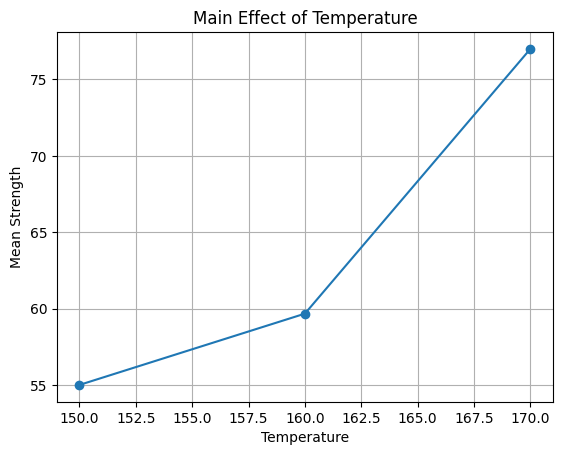

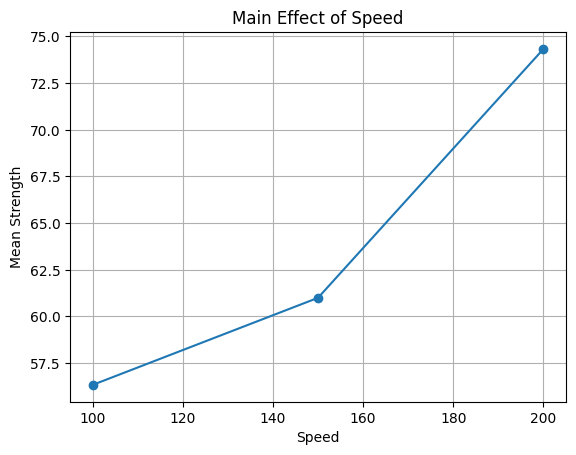

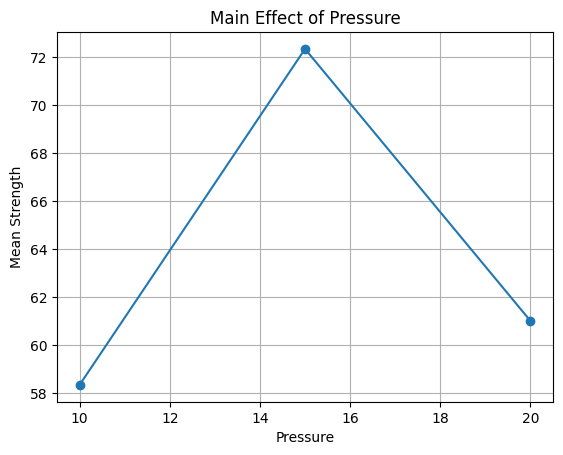

In [ ]:
factors = ["Temperature", "Speed", "Pressure"]
for factor in factors:
    plt.figure()
    df.groupby(factor)["Strength"].mean().plot(marker='o', title=f"Main Effect of {factor}")
    plt.ylabel("Mean Strength")
    plt.grid()
    plt.show()

* Interpretasi
  1. Main Effect of Temperature
      * Tren: Kekuatan meningkat seiring kenaikan temperatur. Dari sekitar 55 (pada 150°C) menjadi hampir 77 (pada 170°C).
      * Interpretasi: Temperatur berpengaruh positif pada Strength—semakin tinggi suhu, semakin kuat produk yang dihasilkan.
      * Catatan: Tren ini hampir linear naik, menunjukkan bahwa efek suhu mungkin dominan. Namun, dari uji ANOVA sebelumnya, efek ini tidak signifikan secara statistik (p = 0.277). Jadi, meskipun ada tren naik, data yang tersedia belum cukup kuat untuk menyatakan efek ini pasti.
  2. Main Effect of Speed
      * Tren: Kekuatan juga meningkat seiring kenaikan kecepatan pencampuran. Dari sekitar 56 (pada 100 rpm) menjadi 74 (pada 200 rpm).
      * Interpretasi: Ada indikasi bahwa peningkatan kecepatan menghasilkan material yang lebih kuat, kemungkinan karena distribusi material lebih homogen.
      * Catatan: Sama seperti suhu, tren ini jelas terlihat, tetapi uji ANOVA memberi p = 0.371 → tidak signifikan dengan sampel kecil ini. Dengan data lebih banyak, bisa jadi efek ini terbukti nyata.
  3. Main Effect of Pressure
      * Tren: Kekuatan meningkat dari 58 (pada 10 bar) ke puncaknya 72 (pada 15 bar), kemudian menurun lagi ke sekitar 61 (pada 20 bar).
      * Interpretasi: Hubungan dengan tekanan berbentuk kurva (non-linear). Ada titik optimum pada tekanan menengah (sekitar 15 bar), di mana kekuatan maksimum dicapai.
      * Catatan: Ini berbeda dari suhu dan kecepatan yang cenderung linier. Meskipun terlihat jelas ada “sweet spot”, ANOVA menghasilkan p = 0.483 → tidak signifikan. Artinya, pola ini bisa saja kebetulan akibat ukuran sampel yang kecil.

## Kesimpulan
1. Secara visual (praktis)
    * Temperatur: tren naik yang jelas—semakin tinggi temperatur, Strength meningkat.
    * Kecepatan (Speed): pola serupa dengan temperatur—semakin cepat, Strength cenderung meningkat.
    * Tekanan (Pressure): berbeda, menunjukkan hubungan non-linear dengan titik optimum di 15 bar.
2. Secara statistik (ANOVA)
    * Tidak ada faktor yang signifikan pada taraf uji α = 0.05 (p-value semua faktor > 0.27).
    * Hal ini bisa terjadi karena jumlah observasi sangat kecil (df residual hanya 2), sehingga daya uji rendah.
    * Jadi, meskipun grafik menunjukkan pola yang logis, bukti statistik belum cukup kuat.

## Rekomendasi
1. Perlu menambah jumlah replikasi → untuk meningkatkan derajat bebas residual dan memperkuat daya uji ANOVA.
2. Pertimbangkan desain lanjutan:
    * Gunakan Response Surface Methodology (RSM), karena ada indikasi hubungan non-linear (terutama pada tekanan).
    * RSM memungkinkan estimasi titik optimum lebih presisi dibanding Taguchi/ANOVA sederhana.
3. Dari sisi praktis industri:
    * Temperatur tinggi (170°C) dan kecepatan tinggi (200 rpm) terlihat menjanjikan dalam meningkatkan Strength.
    * Untuk tekanan, perlu eksperimen tambahan di sekitar 15 bar untuk menguji apakah benar itu titik optimum.
4. Langkah strategis: gunakan data ini sebagai screening awal. Jika benar tren ini terkonfirmasi, bisa masuk tahap optimasi dengan desain percobaan lanjutan.

# Response Surface Methodology (RSM)

## Judul & Latar Belakang Masalah

Industri makanan instan ingin mengoptimalkan proses pengeringan mi instan untuk mendapatkan tekstur yang renyah, tidak mudah patah, dan awet. Tiga faktor utama yang dianggap paling memengaruhi kualitas produk sebagai berikut:
* Suhu pengeringan (°C)
* Kecepatan aliran udara (rpm kipas)
* Waktu pengeringan (menit)

Hubungan antara faktor-faktor tersebut dengan kualitas mi tidak selalu linear; bisa jadi ada efek kuadratik (misalnya terlalu lama justru merusak tekstur) atau interaksi (misalnya suhu tinggi hanya efektif pada waktu tertentu). Karena itu, pendekatan yang cocok adalah Response Surface Methodology (RSM) yang mampu mengeksplorasi efek kuadratik dan mencari kondisi optimum.

## Pertanyaan Penelitian & Hipotesis
* Pertanyaan Penelitian:
  1. Bagaimana pengaruh suhu, kecepatan udara, dan waktu pengeringan terhadap kualitas tekstur mi instan?
  2. Apakah terdapat kombinasi optimal dari ketiga faktor yang menghasilkan tekstur terbaik?
* Hipotesis:

  H₁: Terdapat efek kuadratik pada minimal satu faktor (misalnya suhu terlalu tinggi akan menurunkan kualitas).

  H₂: Terdapat interaksi antara faktor-faktor pengeringan.

  H₃: Ada kombinasi optimum suhu, kecepatan udara, dan waktu yang memaksimalkan kualitas tekstur.

## Desain Percobaan
* Metode: Central Composite Design (CCD)
* Faktor:
    * Suhu (40°C - 80°C)
    * Kecepatan udara (100 - 300 rpm)
    * Waktu pengeringan (10 - 30 menit)
* Response: Skor tekstur (0-100, hasil uji panel sensorik atau pengukuran mekanik).
* Jumlah percobaan: 20 run (termasuk titik pusat untuk replikasi).

## Analisis Statistik

### Import Library

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import plotly.graph_objects as go

np.random.seed(2025)

### Dataset

In [ ]:
n = 20
Temperature = np.random.uniform(40, 80, n)
AirSpeed = np.random.uniform(100, 300, n)
Time = np.random.uniform(10, 30, n)

# model kuadratik dengan interaksi
Texture = (60
           + 0.4*Temperature
           + 0.2*AirSpeed
           + 0.3*Time
           - 0.005*Temperature**2
           - 0.0005*AirSpeed**2
           - 0.01*Time**2
           + 0.002*Temperature*Time
           + np.random.normal(0, 3, n))

df = pd.DataFrame({
    "Temperature": Temperature,
    "AirSpeed": AirSpeed,
    "Time": Time,
    "Texture": Texture
})

### RSM Model

In [ ]:
formula = "Texture ~ (Temperature + AirSpeed + Time)**2 + I(Temperature**2) + I(AirSpeed**2) + I(Time**2)"
model = sm.OLS.from_formula(formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Texture   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     2.522
Date:                Wed, 10 Sep 2025   Prob (F-statistic):             0.0829
Time:                        06:11:46   Log-Likelihood:                -47.630
No. Observations:                  20   AIC:                             115.3
Df Residuals:                      10   BIC:                             125.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               70.0751 

* Interpretasi
  1. Kualitas Model
      * R-squared = 0.694 → sekitar 69,4% variasi pada Texture dapat dijelaskan oleh model.
      * Adj. R-squared = 0.419 → setelah memperhitungkan jumlah prediktor, kemampuan model turun menjadi 41,9%. Artinya, beberapa prediktor mungkin tidak benar-benar penting.
      * F-statistic = 2.522, p = 0.0829 → model secara keseluruhan hampir signifikan pada level 5%, tapi signifikan jika memakai batas 10%. Jadi model ada kecenderungan memberikan informasi berguna, tapi tidak terlalu kuat.
  2. Efek Utama
      * Intercept (70.08, p=0.031) → baseline nilai Texture signifikan berbeda dari nol.
      * Temperature (-0.52, p=0.665) → tidak signifikan. Artinya, suhu linear tidak banyak berpengaruh.
      * AirSpeed (0.24, p=0.108) → mendekati signifikan. Artinya, ada indikasi kecepatan udara berpengaruh positif.
      * Time (1.81, p=0.381) → tidak signifikan. Artinya, durasi tidak banyak berpengaruh secara linear.
  3. Interaksi
      * Temperature x AirSpeed, Temperature x Time, AirSpeed x Time → semua interaksi tidak signifikan (p > 0.4). Artinya kombinasi antar faktor tidak menghasilkan efek berbeda dari efek tunggal masing-masing.
  4. Efek Kuadratik
      * I(Temperature²) (p=0.691) → tidak signifikan.
      * I(AirSpeed²) (p=0.038) → signifikan. Artinya, pengaruh kecepatan udara pada Texture berbentuk kurva (parabola), bukan linear sederhana. Ada titik optimum atau turning point.
      * I(Time²) (p=0.293) → tidak signifikan.
  5. Diagnostik Model
      * Durbin-Watson = 1.933 → mendekati 2, tidak ada masalah autokorelasi.
      * Normalitas residu (Omnibus/JB p>0.5) → residu terlihat normal.
      * Condition number = 1.89e+06 (sangat besar) → ada indikasi multikolinearitas serius, biasanya akibat banyaknya term kuadratik dan interaksi dalam desain dengan jumlah observasi kecil.

### Visualisasi 3D

In [ ]:
temp_range = np.linspace(40, 80, 40)
air_range = np.linspace(100, 300, 40)
Temp, Air = np.meshgrid(temp_range, air_range)
Time_const = 20

df_pred = pd.DataFrame({
    "Temperature": Temp.ravel(),
    "AirSpeed": Air.ravel(),
    "Time": Time_const
})
Texture_pred = model.predict(df_pred).values.reshape(Temp.shape)

fig = go.Figure(data=[go.Surface(
    z=Texture_pred, x=Temp, y=Air,
    colorscale="Viridis"
)])
fig.update_layout(
    title="Response Surface (Texture vs Temp & AirSpeed, Time=20 min)",
    scene=dict(
        xaxis_title="Temperature (°C)",
        yaxis_title="Air Speed (rpm)",
        zaxis_title="Predicted Texture"
    )
)
fig.show()

* Interpretasi
  1. Surface
      * Permukaan melengkung (curved), bukan datar atau linear.
      * Hal ini konsisten dengan hasil analisis sebelumnya, di mana AirSpeed² signifikan, artinya ada efek kuadratik.
  2. Temperature
      * Secara umum, kenaikan suhu dari 40°C → 80°C cenderung menurunkan Texture.
      * Efeknya terlihat gradual, sehingga suhu tinggi mungkin tidak menguntungkan untuk menjaga tekstur.
  3. AirSpeed
      * Terdapat puncak respon (optimum) pada kecepatan udara sekitar 200 rpm.
      * Jika terlalu rendah (<150 rpm), tekstur rendah. Jika terlalu tinggi (>250 rpm), tekstur juga menurun.
      * Inilah bukti nyata dari pengaruh kuadratik AirSpeed.
  4. Interaksi Temperature x AirSpeed
      * Pada suhu rendah (40–50°C) dan kecepatan sedang (200 rpm), Texture diprediksi maksimum (±96).
      * Pada suhu tinggi (>70°C), meskipun kecepatan udara sedang, tekstur tetap menurun.
      * Jadi, optimum hanya bisa tercapai jika kedua faktor berada dalam rentang yang tepat, bukan salah satu saja.
  5. Implikasi Praktis
      * AirSpeed adalah faktor paling kritis untuk dioptimasi.
      * Temperature berperan sebagai faktor penyeimbang, tapi kenaikan berlebihan justru menurunkan kualitas.
      * Pada kondisi Time konstan = 20 menit, kombinasi optimal kira-kira berada di Temperature ~ 50°C dan AirSpeed ~ 200 rpm

## Kesimpulan
* Model RSM menjelaskan sekitar 69% variasi pada respon Texture (R² = 0.694), dengan bukti adanya hubungan non-linear.
* Faktor AirSpeed berpengaruh signifikan secara kuadratik (p = 0.038), artinya ada titik optimum pada nilai menengah (~200 rpm).
* Faktor Temperature cenderung berpengaruh negatif jika terlalu tinggi, meski tidak signifikan secara statistik dalam model.
* Faktor Time dan interaksinya tidak menunjukkan kontribusi besar terhadap Texture dalam kondisi pengujian ini.
* Visualisasi permukaan respon menunjukkan puncak kualitas tekstur (≈96) dicapai pada Temperature ~50°C dan AirSpeed ~200 rpm, dengan waktu konstan 20 menit.

## Rekomendasi
* Optimasi Proses: Atur kondisi pengeringan pada suhu ~50°C dan kecepatan udara ~200 rpm untuk menghasilkan tekstur terbaik.
* Hindari Ekstrem: Jangan gunakan kecepatan udara terlalu rendah (<150 rpm) atau terlalu tinggi (>250 rpm), karena keduanya menurunkan kualitas tekstur.
* Kontrol Suhu: Pertahankan suhu pada level sedang (<60°C) untuk menghindari degradasi tekstur akibat panas berlebih.
* Validasi Eksperimen: Lakukan percobaan konfirmasi di sekitar titik optimum (misalnya suhu 45–55°C dan kecepatan 180–220 rpm) untuk memastikan hasil konsisten.
* Tahap Lanjut: Jika ingin menggeneralisasi, uji variasi waktu (Time) lebih luas untuk memastikan benar-benar tidak berperan penting, atau gunakan desain CCD penuh agar permukaan respon lebih presisi.

# Penutup
Melalui rangkaian eksplorasi rancangan percobaan ini, dapat disimpulkan bahwa setiap desain memiliki keunggulan dan keterbatasannya masing-masing. Tidak ada rancangan tunggal yang mampu menjawab semua permasalahan. Oleh karena itu, pemilihan desain harus disesuaikan dengan tujuan penelitian, jumlah faktor, keterbatasan sumber daya, serta konteks penerapannya.

Penyusunan portofolio ini menjadi sarana refleksi bahwa desain eksperimen bukan hanya sekadar teknik statistik, melainkan seni dalam menyusun pertanyaan dan strategi pengumpulan data. Dengan pemahaman yang baik, rancangan eksperimen mampu menjembatani antara teori dan praktik, serta memastikan bahwa keputusan yang diambil memiliki dasar yang kuat.

Semoga portofolio ini dapat bermanfaat tidak hanya sebagai dokumentasi pembelajaran, tetapi juga sebagai referensi praktis bagi siapa pun yang ingin mendalami desain eksperimen dalam dunia industri maupun penelitian.

# Thank You